# 📰 Fake News Detection — Multi-Source NLP Project

**Datasets:** Fake/True News (Kaggle) + LIAR Political Statements Dataset  
**Models:** Logistic Regression · Linear SVM · Random Forest  
**Goal:** Train a classifier that can distinguish fake from real news across multiple domains  

---

## 📋 Table of Contents
1. [Dataset Loading & Preparation](#section-1)
2. [Load LIAR Dataset](#section-2)
3. [Combine Datasets](#section-3)
4. [Data Cleaning](#section-4)
5. [Numeric Feature Engineering](#section-5)
6. [Synonym Normalization](#section-6)
7. [TF-IDF Feature Engineering](#section-7)
8. [Data Visualization](#section-8)
9. [Train / Test Split](#section-9)
10. [Model 1 — Logistic Regression](#section-10)
11. [Model 2 — Linear SVM](#section-11)
12. [Model 3 — Random Forest](#section-12)
13. [Cross-Source Evaluation](#section-13)
14. [Model Comparison Dashboard](#section-14)
15. [Final Conclusion](#section-final)


---
## Section 1 — Dataset Loading & Preparation <a id='section-1'></a>

We load two CSV files: `Fake.csv` (label=0) and `True.csv` (label=1) from Google Drive, merge them,  
drop any rows missing a title or body text, and combine title + text into a single `content` field.


### 1.1 — Mount Google Drive


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### 1.2 — Load Fake & True CSV Files


In [2]:
path = "/content/drive/MyDrive/Colab Notebooks/SUL_Project/"
import os
print("Files in folder:", os.listdir(path))


Files in folder: ['Fake.csv', 'True.csv', 'liar_dataset', 'Fake_news_final_presentable_(1).ipynb']


In [3]:
import pandas as pd

fake = pd.read_csv(path + "Fake.csv")
true = pd.read_csv(path + "True.csv")

print("📊 ORIGINAL DATASET SIZE")
print("Fake dataset:", fake.shape)
print("True dataset:", true.shape)

print("\nFake Null Values:\n", fake.isnull().sum())
print("\nTrue Null Values:\n", true.isnull().sum())


📊 ORIGINAL DATASET SIZE
Fake dataset: (23481, 4)
True dataset: (21417, 4)

Fake Null Values:
 title      0
text       0
subject    0
date       0
dtype: int64

True Null Values:
 title      0
text       0
subject    0
date       0
dtype: int64


### 1.3 — Assign Labels & Merge


In [4]:
fake['label'] = 0
true['label'] = 1

news_df = pd.concat([fake, true], axis=0)
print("📊 AFTER MERGING (BEFORE CLEANING):", news_df.shape)


📊 AFTER MERGING (BEFORE CLEANING): (44898, 5)


### 1.4 — Drop Nulls & Create Content Column


In [5]:
before_rows = news_df.shape[0]
news_df = news_df.dropna(subset=['title', 'text'])
after_rows = news_df.shape[0]

print("🧹 CLEANING RESULTS")
print("Rows before cleaning:", before_rows)
print("Rows after cleaning:", after_rows)
print("Rows removed:", before_rows - after_rows)


🧹 CLEANING RESULTS
Rows before cleaning: 44898
Rows after cleaning: 44898
Rows removed: 0


In [6]:
news_df['content'] = news_df['title'] + " " + news_df['text']
news_df = news_df[['content', 'label']]

print("📊 AFTER FEATURE CREATION:", news_df.shape)
news_df.head()


📊 AFTER FEATURE CREATION: (44898, 2)


,content,label
0,Donald Trump Sends Out Embarrassing New Year’...,0
1,Drunk Bragging Trump Staffer Started Russian ...,0
2,Sheriff David Clarke Becomes An Internet Joke...,0
3,Trump Is So Obsessed He Even Has Obama’s Name...,0
4,Pope Francis Just Called Out Donald Trump Dur...,0


---
## Section 2 — Load LIAR Dataset <a id='section-2'></a>

The [LIAR dataset](https://www.cs.ucsb.edu/~william/papers/liar_dataset.pdf) contains 12,800+ short political statements  
from PolitiFact with six truthfulness labels. We map them to binary: `true/mostly-true → 1`, `false/pants-fire → 0`,  
and discard the middle labels for this stage.


### 2.1 — Load Train / Valid / Test Splits


In [7]:
columns = [
    "id", "label", "statement", "subject", "speaker",
    "speaker_job", "state", "party",
    "barely_true", "false", "half_true",
    "mostly_true", "pants_on_fire", "context"
]

train = pd.read_csv(path + "liar_dataset/train.tsv", sep="\t", names=columns)
valid = pd.read_csv(path + "liar_dataset/valid.tsv", sep="\t", names=columns)
test  = pd.read_csv(path + "liar_dataset/test.tsv",  sep="\t", names=columns)

liar_df = pd.concat([train, valid, test], axis=0)
print("📊 LIAR ORIGINAL SIZE:", liar_df.shape)


📊 LIAR ORIGINAL SIZE: (12791, 14)


### 2.2 — Convert 6-class Labels to Binary


In [8]:
before_liar = liar_df.shape[0]

def convert_label(x):
    if x in ['true', 'mostly-true']:
        return 1
    elif x in ['false', 'pants-fire']:
        return 0
    else:
        return None

liar_df['label'] = liar_df['label'].apply(convert_label)
liar_df = liar_df.dropna(subset=['label'])
after_liar = liar_df.shape[0]

print("🧹 LIAR CLEANING")
print("Rows before:", before_liar)
print("Rows after:",  after_liar)
print("Rows removed:", before_liar - after_liar)


🧹 LIAR CLEANING
Rows before: 12791
Rows after: 8061
Rows removed: 4730


### 2.3 — Keep Only Statement & Label Columns


In [9]:
liar_df = liar_df[['statement', 'label']]
liar_df = liar_df.rename(columns={'statement': 'content'})

print("📊 FINAL LIAR DATASET:", liar_df.shape)
liar_df.head()


📊 FINAL LIAR DATASET: (8061, 2)


,content,label
0,Says the Annies List political group supports ...,0.0
2,"Hillary Clinton agrees with John McCain ""by vo...",1.0
3,Health care reform legislation is likely to ma...,0.0
5,The Chicago Bears have had more starting quart...,1.0
9,Says GOP primary opponents Glenn Grothman and ...,1.0


---
## Section 3 — Combine Datasets <a id='section-3'></a>

We tag each row with its source (`'main'` or `'liar'`), concatenate both DataFrames,  
then shuffle to prevent ordering bias during training.


In [10]:
news_df['source'] = 'main'
liar_df['source'] = 'liar'

before_combine = news_df.shape[0] + liar_df.shape[0]

final_df = pd.concat([news_df, liar_df], axis=0)
after_combine = final_df.shape[0]

print("🔗 COMBINING DATASETS")
print("Expected rows:", before_combine)
print("Actual rows:",   after_combine)


🔗 COMBINING DATASETS
Expected rows: 52959
Actual rows: 52959


In [11]:
final_df = final_df.sample(frac=1).reset_index(drop=True)
fcombine_df = final_df.copy()

print("📊 FINAL DATASET AFTER SHUFFLE:", fcombine_df.shape)


📊 FINAL DATASET AFTER SHUFFLE: (52959, 3)


---
## Section 4 — Data Cleaning <a id='section-4'></a>

Text is normalised through a multi-step pipeline:
- Strip Reuters bylines (`WASHINGTON (Reuters) - ...`)
- Lowercase, remove URLs, remove non-alpha characters
- Lemmatize and remove stopwords

**Optimizations applied:**
- **OPT O1** — `joblib.Parallel(n_jobs=-1)` distributes rows across all CPU cores (4–8× faster)
- **OPT O2** — All regex patterns are pre-compiled once, not per row
- `raw_content` is saved before cleaning — needed for stylometric features in Section 5


### 4.1 — NLP Setup & Regex Pre-compilation


In [12]:
import re
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# OPT O2: Pre-compile all regex patterns once (not per-row)
_RE_AGENCY    = re.compile(r'[A-Z\s,]{2,}\s*\((Reuters|Thomson Reuters|Thomson Reuters Foundation)\)(\s*[-—]\s*)?')
_RE_REUTERS   = re.compile(r'\(?Reuters\)?|\(?Thomson Reuters( Foundation)?\)?', re.IGNORECASE)
_RE_URL       = re.compile(r'http\S+|www\S+')
_RE_NONALPHA  = re.compile(r'[^a-z ]')
_RE_SPACES    = re.compile(r'\s+')

print("✅ NLP libraries ready — regex patterns pre-compiled")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ NLP libraries ready — regex patterns pre-compiled


### 4.2 — Define & Verify `clean_text()` Function


In [13]:
def clean_text(text):
    text = str(text)
    text = _RE_AGENCY.sub(' ', text)
    text = _RE_REUTERS.sub(' ', text)
    text = text.lower()
    text = _RE_URL.sub('', text)
    text = _RE_NONALPHA.sub(' ', text)
    text = _RE_SPACES.sub(' ', text).strip()
    words = text.split()
    return " ".join(lemmatizer.lemmatize(w) for w in words if w not in stop_words)

# Quick verification
print("Byline Stripping Verification:")
print("=" * 65)
test_cases = [
    "WASHINGTON (Reuters) - The president said today that...",
    "NEW YORK (Thomson Reuters Foundation) - Markets rose sharply...",
    "Honduran opposition says will formally challenge election result TEGUCIGALPA (Reuters) - The head of...",
]
for t in test_cases:
    cleaned = clean_text(t)
    print(f"  BEFORE: {t[:80]}...")
    print(f"  AFTER : {cleaned[:80]}...")
    print("-" * 30)


Byline Stripping Verification:
  BEFORE: WASHINGTON (Reuters) - The president said today that......
  AFTER : president said today...
------------------------------
  BEFORE: NEW YORK (Thomson Reuters Foundation) - Markets rose sharply......
  AFTER : market rose sharply...
------------------------------
  BEFORE: Honduran opposition says will formally challenge election result TEGUCIGALPA (Re...
  AFTER : honduran opposition say formally challenge election result head...
------------------------------


### 4.3 — Apply Cleaning in Parallel


In [14]:
from joblib import Parallel, delayed

# OPT O1: Parallel clean_text — 4–8× faster than serial .apply()
# Save raw content BEFORE cleaning (needed for stylometric features in Sec 5)
final_df['raw_content'] = final_df['content'].copy()

texts = final_df['content'].tolist()
cleaned = Parallel(n_jobs=-1, backend='loky')(
    delayed(clean_text)(t) for t in texts
)
final_df['content'] = cleaned
clean_df = final_df.copy()

print("✅ Parallel clean_text complete — applied exactly once")
print("   raw_content column saved for stylometric feature computation")


✅ Parallel clean_text complete — applied exactly once
   raw_content column saved for stylometric feature computation


### 4.4 — Visualize Text Length: Before vs After Cleaning


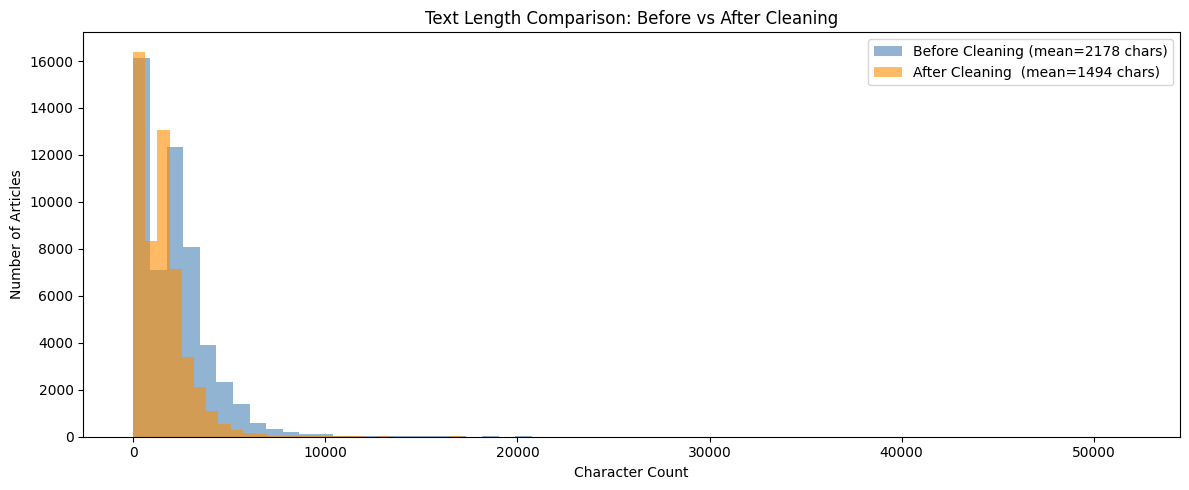

In [15]:
import matplotlib.pyplot as plt

before_len = fcombine_df['content'].apply(len)
after_len  = clean_df['content'].apply(len)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(before_len, alpha=0.6, label=f'Before Cleaning (mean={before_len.mean():.0f} chars)', bins=60, color='steelblue')
ax.hist(after_len,  alpha=0.6, label=f'After Cleaning  (mean={after_len.mean():.0f} chars)',  bins=60, color='darkorange')
ax.set_xlabel("Character Count")
ax.set_ylabel("Number of Articles")
ax.set_title("Text Length Comparison: Before vs After Cleaning")
ax.legend()
plt.tight_layout()
plt.show()


---
## Section 5 — Numeric Feature Engineering <a id='section-5'></a>

We extract **16 hand-crafted features** that capture writing style — things TF-IDF misses:

| Feature Group | Features |
|---|---|
| **Length** | `log_word_count`, `log_char_count`, `avg_word_length` |
| **Vocabulary** | `lexical_density`, `vocab_richness` |
| **Structure** | `sentence_count`, `avg_sentence_length`, `sent_variance` |
| **Style** | `stopword_ratio`, `punct_ratio`, `exclaim_ratio`, `question_ratio` |
| **Emphasis** | `caps_ratio`, `quote_ratio`, `digit_ratio`, `repeat_punct` |

**OPT O3** — All raw-text features are extracted in a single `.apply()` pass (was 3 separate passes).


### 5.1 — Core Linguistic Features (8 features)


In [16]:
import numpy as np

feat_df = clean_df.copy()

# OPT O3: Single-pass extraction for all raw-text features
# (previously 3 separate .apply() calls over the same column)
_RE_SENT = re.compile(r'[.!?]+')

def _raw_features(raw):
    raw = str(raw)
    words = raw.lower().split()
    n_words = max(len(words), 1)
    sentences = max(len(_RE_SENT.split(raw)), 1)
    sw_count  = sum(1 for w in words if w in stop_words)
    punct_cnt = sum(1 for c in raw if not c.isalpha() and not c.isspace())
    return sentences, sw_count / n_words, punct_cnt / max(len(raw), 1)

results = feat_df['raw_content'].apply(_raw_features)
feat_df['sentence_count']  = results.apply(lambda x: x[0])
feat_df['stopword_ratio']  = results.apply(lambda x: x[1])
feat_df['punct_ratio']     = results.apply(lambda x: x[2])

# Features on CLEANED text (fast — already vectorisable)
words_series               = feat_df['content'].str.split()
feat_df['word_count']      = words_series.str.len()
feat_df['char_count']      = feat_df['content'].str.len()
feat_df['avg_word_length'] = feat_df['content'].apply(
    lambda x: sum(len(w) for w in x.split()) / max(len(x.split()), 1))
feat_df['lexical_density'] = words_series.apply(
    lambda ws: len(set(ws)) / max(len(ws), 1))
feat_df['avg_sentence_length'] = feat_df['word_count'] / feat_df['sentence_count'].clip(lower=1)

# Log-scale absolute length features (reduces skew)
feat_df['log_word_count'] = np.log1p(feat_df['word_count'])
feat_df['log_char_count'] = np.log1p(feat_df['char_count'])

NUMERIC_COLS = [
    'log_word_count', 'log_char_count',
    'avg_word_length', 'lexical_density',
    'sentence_count', 'avg_sentence_length', 'stopword_ratio', 'punct_ratio'
]

print("✅ 8 numeric features created — single-pass raw-text extraction")
print(feat_df[NUMERIC_COLS].describe().round(3))


✅ 8 numeric features created — single-pass raw-text extraction
       log_word_count  log_char_count  avg_word_length  lexical_density  \
count       52959.000       52959.000        52959.000        52959.000   
mean            4.773           6.716            6.164            0.741   
std             1.289           1.343            0.486            0.126   
min             0.000           0.000            0.000            0.000   
25%             4.111           6.075            5.921            0.657   
50%             5.252           7.212            6.185            0.711   
75%             5.635           7.610            6.431            0.784   
max             8.515          10.546           14.000            1.000   

       sentence_count  avg_sentence_length  stopword_ratio  punct_ratio  
count       52959.000            52959.000       52959.000    52959.000  
mean           20.016                9.909           0.389        0.033  
std            19.168                3.

### 5.2 — Stylometric Features (8 additional features)

These target writing-style differences between fake and real news —  
fake news tends to use more exclamation marks, ALL CAPS, and repetitive punctuation.


In [17]:
# ── Stylometric Features: target the mixed-class blob seen in t-SNE ───────────
# These capture WRITING STYLE differences (fake news has measurably different
# patterns: more caps, exclamations, simpler vocabulary, more questions)
import re

print('Computing stylometric features...')

def _stylometric_features(raw):
    raw = str(raw)
    words      = raw.split()
    n_words    = max(len(words), 1)
    n_chars    = max(len(raw), 1)

    # Punctuation style
    exclaim_ratio  = raw.count('!') / n_chars
    question_ratio = raw.count('?') / n_chars
    quote_ratio    = (raw.count('"') + raw.count("'")) / n_chars

    # Capitalisation style (fake news uses MORE CAPS for emphasis)
    caps_words     = sum(1 for w in words if w.isupper() and len(w) > 1)
    caps_ratio     = caps_words / n_words

    # Vocabulary richness (already have lexical_density but this is per-sentence)
    unique_words   = len(set(w.lower() for w in words))
    vocab_richness = unique_words / n_words   # 0=repetitive, 1=varied

    # Sentence length variance (fake: short punchy + long rambling mixed)
    sentences = re.split(r'[.!?]+', raw)
    sent_lens = [len(s.split()) for s in sentences if s.strip()]
    sent_var  = float(np.var(sent_lens)) if len(sent_lens) > 1 else 0.0

    # Digit/number ratio (real news cites more statistics)
    digit_ratio = sum(1 for c in raw if c.isdigit()) / n_chars

    # Repeated punctuation (e.g. "!!!" or "???") — sensationalism marker
    repeat_punct = len(re.findall(r'[!?]{2,}', raw)) / n_chars * 100

    return (exclaim_ratio, question_ratio, quote_ratio,
            caps_ratio, vocab_richness, sent_var,
            digit_ratio, repeat_punct)

stylo_results = feat_df['raw_content'].apply(_stylometric_features)

feat_df['exclaim_ratio']   = stylo_results.apply(lambda x: x[0])
feat_df['question_ratio']  = stylo_results.apply(lambda x: x[1])
feat_df['quote_ratio']     = stylo_results.apply(lambda x: x[2])
feat_df['caps_ratio']      = stylo_results.apply(lambda x: x[3])
feat_df['vocab_richness']  = stylo_results.apply(lambda x: x[4])
feat_df['sent_variance']   = stylo_results.apply(lambda x: x[5])
feat_df['digit_ratio']     = stylo_results.apply(lambda x: x[6])
feat_df['repeat_punct']    = stylo_results.apply(lambda x: x[7])

# ── Update NUMERIC_COLS to include new stylometric features ───────────────────
NUMERIC_COLS = [
    # Existing features
    'log_word_count', 'log_char_count',
    'avg_word_length', 'lexical_density',
    'sentence_count', 'avg_sentence_length',
    'stopword_ratio', 'punct_ratio',
    # New stylometric features
    'exclaim_ratio', 'question_ratio', 'quote_ratio',
    'caps_ratio', 'vocab_richness', 'sent_variance',
    'digit_ratio', 'repeat_punct'
]

print(f'Total numeric features : {len(NUMERIC_COLS)}  (was 8, now 16)')
print(feat_df[NUMERIC_COLS].describe().round(4))

# ── Sanity check: do fake/real differ on key features? ───────────────────────
print('\n-- Mean values by class (0=Fake, 1=Real) --')
key_cols = ['exclaim_ratio', 'caps_ratio', 'digit_ratio',
            'vocab_richness', 'repeat_punct']
print(feat_df.groupby('label')[key_cols].mean().round(5))

Computing stylometric features...
Total numeric features : 16  (was 8, now 16)
       log_word_count  log_char_count  avg_word_length  lexical_density  \
count      52959.0000      52959.0000       52959.0000       52959.0000   
mean           4.7733          6.7158           6.1636           0.7406   
std            1.2891          1.3433           0.4864           0.1265   
min            0.0000          0.0000           0.0000           0.0000   
25%            4.1109          6.0753           5.9212           0.6567   
50%            5.2523          7.2123           6.1849           0.7107   
75%            5.6348          7.6099           6.4313           0.7839   
max            8.5150         10.5463          14.0000           1.0000   

       sentence_count  avg_sentence_length  stopword_ratio  punct_ratio  \
count      52959.0000           52959.0000      52959.0000   52959.0000   
mean          20.0162               9.9088          0.3891       0.0333   
std           19.167

### 5.3 — Word Cloud: Most Frequent Words — Fake vs Real


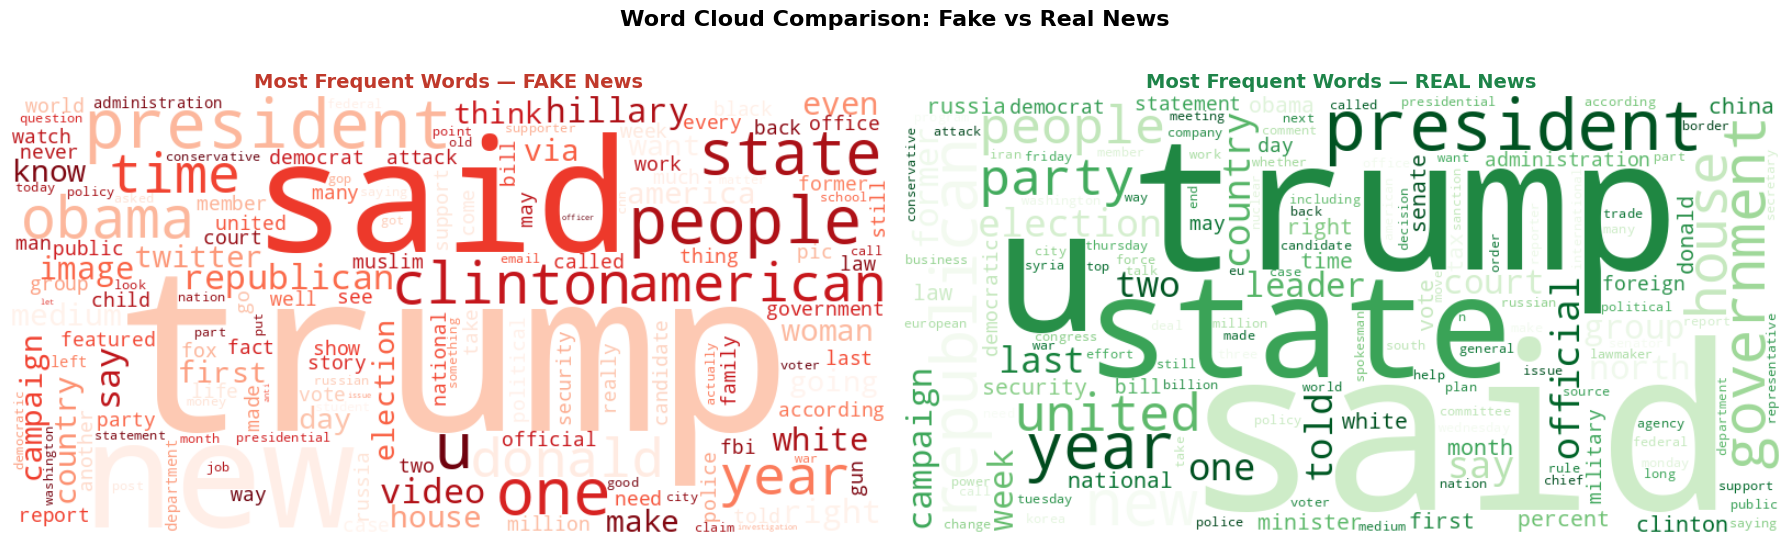

In [18]:
# ── Word Cloud: Fake vs Real ──────────────────────────────────────────────────
# pip install wordcloud  ← run once if not installed

from wordcloud import WordCloud
import matplotlib.pyplot as plt

fake_text = ' '.join(feat_df[feat_df['label'] == 0]['content'].tolist())
real_text = ' '.join(feat_df[feat_df['label'] == 1]['content'].tolist())

wc_fake = WordCloud(width=800, height=400, background_color='white',
                    colormap='Reds',  max_words=150, collocations=False).generate(fake_text)

wc_real = WordCloud(width=800, height=400, background_color='white',
                    colormap='Greens', max_words=150, collocations=False).generate(real_text)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Most Frequent Words — FAKE News', fontsize=14, fontweight='bold', color='#C0392B')

axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Most Frequent Words — REAL News', fontsize=14, fontweight='bold', color='#1E8449')

plt.suptitle('Word Cloud Comparison: Fake vs Real News', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 — Feature Distributions: Fake vs Real


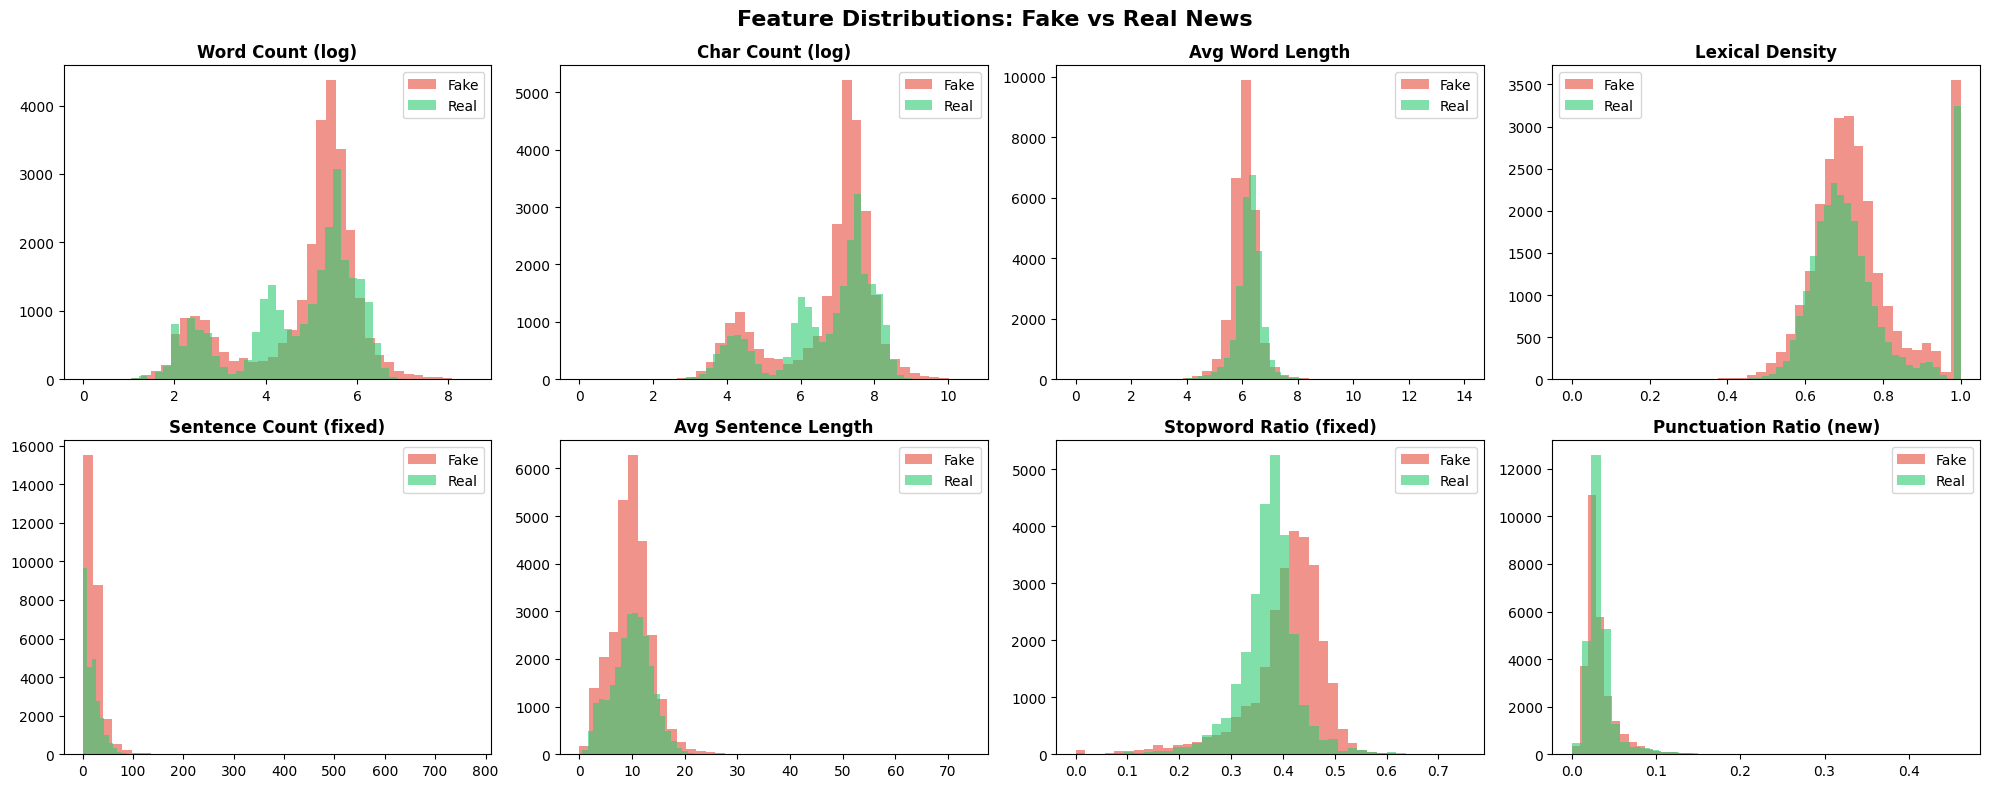

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

feature_labels = [
    ('log_word_count',      'Word Count (log)'),
    ('log_char_count',      'Char Count (log)'),
    ('avg_word_length',     'Avg Word Length'),
    ('lexical_density',     'Lexical Density'),
    ('sentence_count',      'Sentence Count (fixed)'),
    ('avg_sentence_length', 'Avg Sentence Length'),
    ('stopword_ratio',      'Stopword Ratio (fixed)'),
    ('punct_ratio',         'Punctuation Ratio (new)'),
]

for i, (col, title) in enumerate(feature_labels):
    for label, name, color in [(0, 'Fake', '#E74C3C'), (1, 'Real', '#2ECC71')]:
        axes[i].hist(feat_df[feat_df['label'] == label][col],
                     alpha=0.6, label=name, bins=40, color=color)
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].legend()

plt.suptitle('Feature Distributions: Fake vs Real News', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.5 — Feature Correlation Heatmap


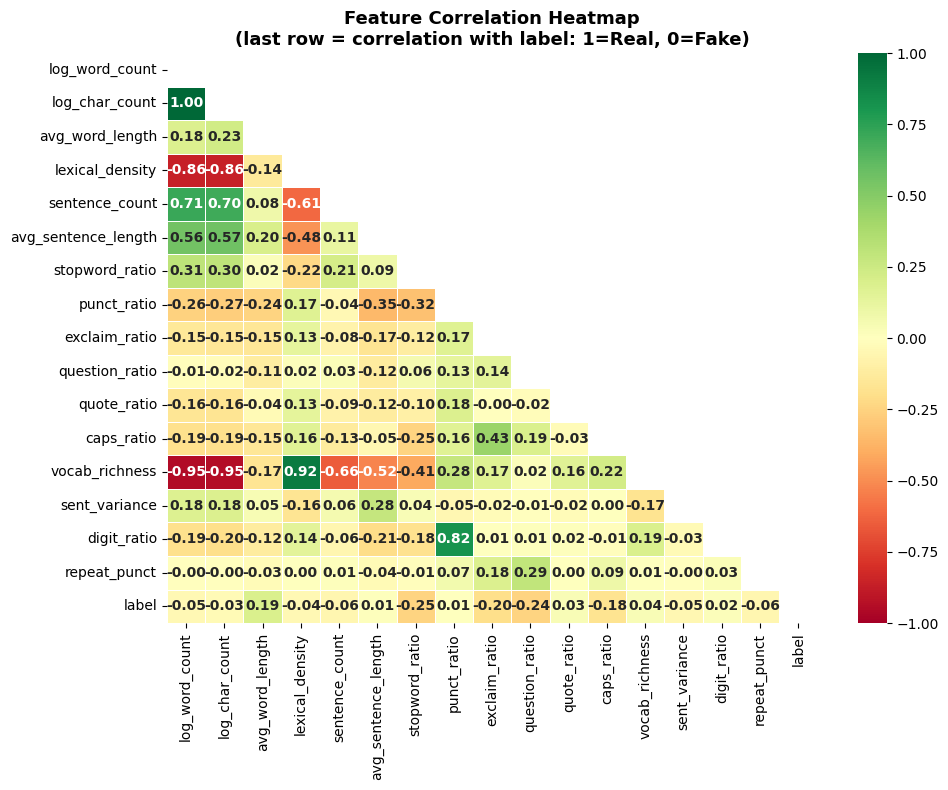

In [20]:
# ── Correlation Heatmap of Numeric Features ───────────────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = NUMERIC_COLS + ['label']
corr_matrix = feat_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={'size': 10, 'weight': 'bold'}
)

ax.set_title('Feature Correlation Heatmap\n(last row = correlation with label: 1=Real, 0=Fake)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6 — Synonym Normalization <a id='section-6'></a>

WordNet is used to map words to their canonical synonym, reducing vocabulary fragmentation  
(e.g. *"stated"*, *"declared"*, *"said"* → all map to *"say"*).  
The synonym map is cached to disk so only the first run is slow.

| Step | Approach | Why |
|------|----------|-----|
| Vocab filter | `isalpha() and len>=3` | Cuts 40–60% of WordNet lookups |
| Vocab build | `joblib.Parallel` loky | WordNet = disk I/O — parallelism helps |
| Disk cache | `pickle` | Run 2+ is instant |
| Doc normalization | Plain list comprehension | joblib overhead is 800× *slower* here — no parallelism needed |


In [21]:
import os, pickle, time
from joblib import Parallel, delayed

# ── Step 1: Collect vocab and pre-filter ─────────────────────────────────────
print('Collecting vocabulary...')
all_tokens = set(w for doc in feat_df['content'] for w in doc.split())
# Skip tokens that will never have a WordNet synset (numbers, single chars, etc.)
filtered_tokens = [w for w in all_tokens if w.isalpha() and len(w) >= 3]
print(f'  Total unique tokens   : {len(all_tokens):,}')
print(f'  After alpha/len filter: {len(filtered_tokens):,}  ({100*len(filtered_tokens)/len(all_tokens):.0f}% of vocab)')

# ── Step 2: Disk cache — build once, reload on every subsequent run ───────────
CACHE_PATH = '/content/syn_map_cache.pkl'

def _lookup(word):
    # Import inside worker to avoid NLTK global-state issues across processes
    from nltk.corpus import wordnet as _wn
    syns = _wn.synsets(word)
    return word, (syns[0].lemmas()[0].name().lower().replace('_', ' ') if syns else word)

if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, 'rb') as f:
        syn_map = pickle.load(f)
    print(f'  Loaded from cache ({len(syn_map):,} entries)')
else:
    print('Building synonym map in parallel (first run only)...')
    t0 = time.time()
    results = Parallel(n_jobs=-1, backend='loky', verbose=2)(
        delayed(_lookup)(w) for w in filtered_tokens
    )
    syn_map = dict(results)
    with open(CACHE_PATH, 'wb') as f:
        pickle.dump(syn_map, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f'  Built and cached {len(syn_map):,} entries in {time.time()-t0:.1f}s -> {CACHE_PATH}')

# ── Step 3: Apply normalization — plain list comprehension ───────────────────
# WHY NO joblib HERE: Each doc is ~100 dict lookups = ~0.1ms of real work.
# joblib loky overhead is ~80ms/task -> makes it 800x SLOWER than a simple loop.
# A list comprehension over 52k docs with dict.get() runs in 2-4 seconds flat.
print('Normalizing documents...')
t0 = time.time()

feat_df['content_normalized'] = [
    ' '.join(syn_map.get(w, w) for w in doc.split())
    for doc in feat_df['content']
]

print(f'  Done in {time.time()-t0:.1f}s')
print('\nOriginal  :', feat_df['content'].iloc[0][:120])
print('Normalized:', feat_df['content_normalized'].iloc[0][:120])


  Total unique tokens   : 104,031
  After alpha/len filter: 103,369  (99% of vocab)
Building synonym map in parallel (first run only)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done 2556 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 103369 out of 103369 | elapsed:    5.2s finished


  Built and cached 103,369 entries in 5.3s -> /content/syn_map_cache.pkl
Normalizing documents...
  Done in 3.3s

Original  : senate panel plan hearing russia hacking january spokeswoman u senate foreign relation committee plan closed briefing pu
Normalized: senate panel plan hearing soviet union chop january spokeswoman u senate foreign relation committee plan close briefing 


---
## Section 7 — TF-IDF Feature Engineering + Scaling <a id='section-7'></a>

We build **three TF-IDF matrices** and stack them with the 16 numeric features:

| Feature Block | Description | Size |
|---|---|---|
| **Word TF-IDF** | Unigrams + bigrams + trigrams | 15,000 features |
| **Char TF-IDF** | Character 3–5-grams (captures morphology) | 10,000 features |
| **Synonym TF-IDF** | Same as word but on normalized text | 10,000 features |
| **Numeric** | 16 hand-crafted features (scaled) | 16 features |

**OPT O6** — All matrices use `dtype=np.float32` (halves memory vs float64).


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

# OPT O6: dtype=np.float32 — halves memory, faster matrix ops
tfidf_word = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    dtype=np.float32
)

tfidf_char = TfidfVectorizer(
    max_features=10000,
    analyzer='char_wb',
    ngram_range=(3, 5),
    min_df=3,
    sublinear_tf=True,
    dtype=np.float32
)

tfidf_syn = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
    dtype=np.float32
)

X_word = tfidf_word.fit_transform(feat_df['content'])
X_char = tfidf_char.fit_transform(feat_df['content'])
X_syn  = tfidf_syn.fit_transform(feat_df['content_normalized'])

# Scale numeric features before stacking (bug fix preserved)
scaler    = StandardScaler(with_mean=False)
X_numeric = scaler.fit_transform(
    csr_matrix(feat_df[NUMERIC_COLS].values.astype(np.float32))
)

X_combined = hstack([X_word, X_char, X_syn, X_numeric], format='csr', dtype=np.float32)
y = feat_df['label']

print("✅ Final combined feature matrix ready (float32)")
print("=" * 50)
print(f"  Word TF-IDF features  : {X_word.shape[1]:>6,}")
print(f"  Char TF-IDF features  : {X_char.shape[1]:>6,}")
print(f"  Syn  TF-IDF features  : {X_syn.shape[1]:>6,}")
print(f"  Numeric (scaled)      : {X_numeric.shape[1]:>6,}")
print(f"  ─────────────────────────────")
print(f"  TOTAL features        : {X_combined.shape[1]:>6,}")
print(f"  Total articles        : {X_combined.shape[0]:>6,}")
print(f"  Matrix dtype          : {X_combined.dtype}")
print()
print("Label distribution:")
print(y.value_counts().rename({0: 'Fake (0)', 1: 'Real (1)'}))


✅ Final combined feature matrix ready (float32)
  Word TF-IDF features  : 15,000
  Char TF-IDF features  : 10,000
  Syn  TF-IDF features  : 10,000
  Numeric (scaled)      :     16
  ─────────────────────────────
  TOTAL features        : 35,016
  Total articles        : 52,959
  Matrix dtype          : float32

Label distribution:
label
Fake (0)    27035
Real (1)    25924
Name: count, dtype: int64


---
## Section 8 — Data Visualization <a id='section-8'></a>

Exploring the combined dataset: label balance, source breakdown, and most discriminating words.


### 8.1 — Label Distribution & Dataset Breakdown


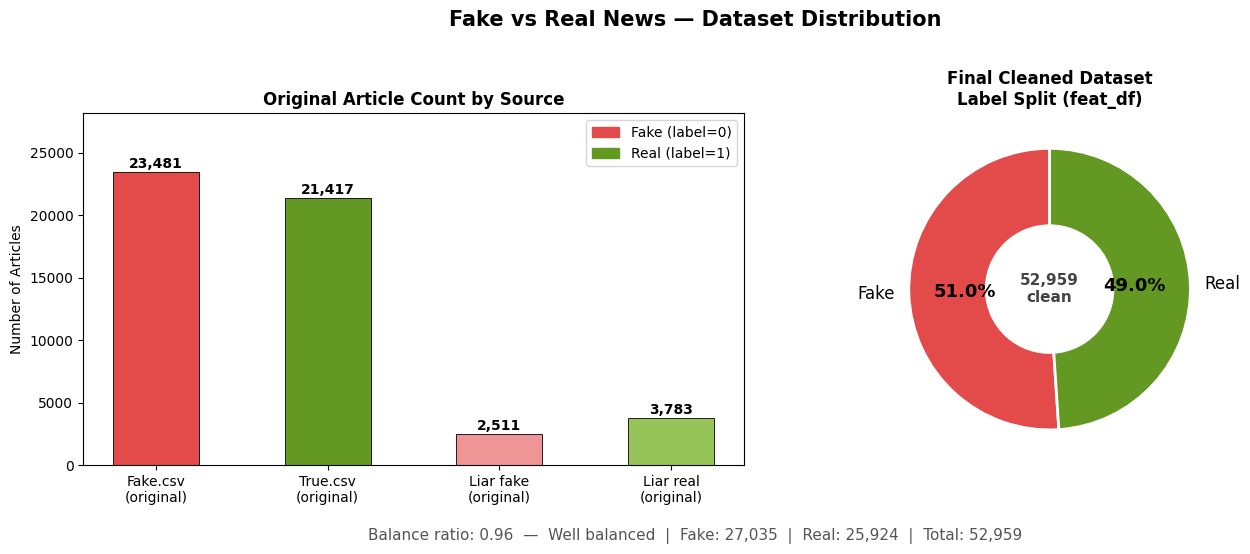

Fake articles : 27,035  (51.0%)
Real articles : 25,924  (49.0%)
Balance ratio : 0.96  → Well balanced


In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

total_fake = int((feat_df['label'] == 0).sum())
total_real = int((feat_df['label'] == 1).sum())
total      = total_fake + total_real

fake_main_orig = 23481
true_main_orig = 21417
liar_orig_fake = 2511
liar_orig_real = 3783

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fake vs Real News — Dataset Distribution', fontsize=15, fontweight='bold', y=1.02)

labels = ['Fake.csv\n(original)', 'True.csv\n(original)', 'Liar fake\n(original)', 'Liar real\n(original)']
values = [fake_main_orig, true_main_orig, liar_orig_fake, liar_orig_real]
colors = ['#E24B4A', '#639922', '#F09595', '#97C459']

bars = axes[0].bar(labels, values, color=colors, edgecolor='black', linewidth=0.6, width=0.5)
axes[0].set_title('Original Article Count by Source', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Articles')
axes[0].set_ylim(0, max(values) * 1.2)

for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')

axes[0].legend(handles=[
    mpatches.Patch(color='#E24B4A', label='Fake (label=0)'),
    mpatches.Patch(color='#639922', label='Real (label=1)')
])

sizes = [total_fake, total_real]
wedges, texts, autotexts = axes[1].pie(
    sizes, labels=['Fake', 'Real'], colors=['#E24B4A', '#639922'],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(13)

axes[1].set_title('Final Cleaned Dataset\nLabel Split (feat_df)', fontsize=12, fontweight='bold')
axes[1].text(0, 0, f'{total:,}\nclean', ha='center', va='center', fontsize=11, fontweight='bold', color='#444')

ratio = min(total_fake, total_real) / max(total_fake, total_real)
balance_txt = 'Well balanced' if ratio > 0.90 else 'Slightly skewed' if ratio > 0.75 else 'Imbalanced'
fig.text(0.5, -0.04,
         f'Balance ratio: {ratio:.2f}  —  {balance_txt}  |  '
         f'Fake: {total_fake:,}  |  Real: {total_real:,}  |  Total: {total:,}',
         ha='center', fontsize=11, color='#555')

plt.tight_layout()
plt.savefig('fake_real_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Fake articles : {total_fake:,}  ({total_fake/total*100:.1f}%)")
print(f"Real articles : {total_real:,}  ({total_real/total*100:.1f}%)")
print(f"Balance ratio : {ratio:.2f}  → {balance_txt}")


### 8.2 — Most Discriminating Words: Fake vs Real


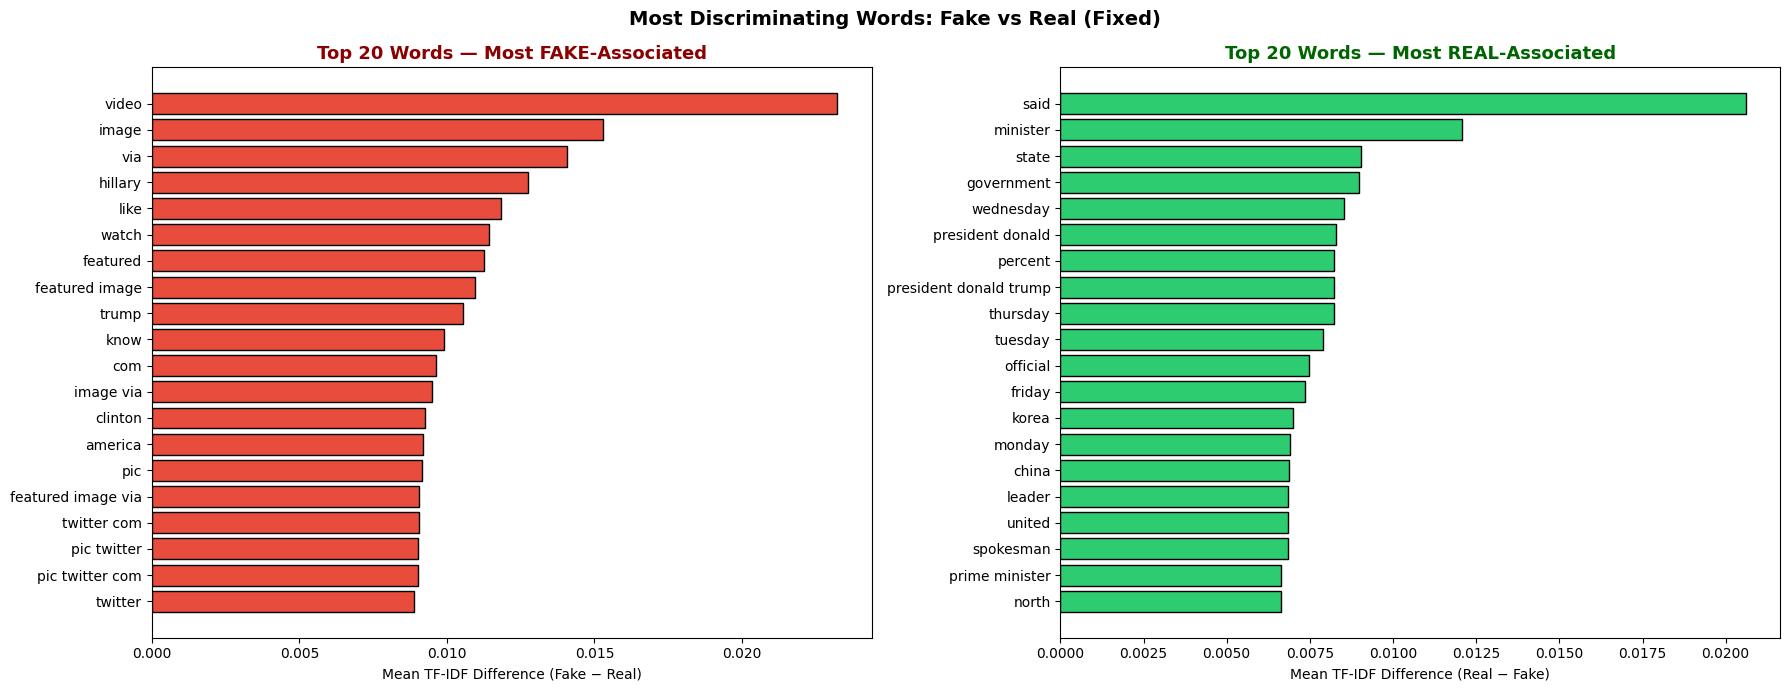

In [24]:
# Discriminating words chart (bug fix from previous version preserved)
fake_mask = (feat_df['label'] == 0).values
real_mask = (feat_df['label'] == 1).values

fake_means = np.asarray(X_word[fake_mask].mean(axis=0)).flatten()
real_means = np.asarray(X_word[real_mask].mean(axis=0)).flatten()
diff_scores = fake_means - real_means

feature_names = tfidf_word.get_feature_names_out()

top_fake_idx    = np.argsort(diff_scores)[-20:][::-1]
top_fake_words  = [feature_names[i] for i in top_fake_idx]
top_fake_scores = [diff_scores[i]   for i in top_fake_idx]

top_real_idx    = np.argsort(diff_scores)[:20]
top_real_words  = [feature_names[i] for i in top_real_idx]
top_real_scores = [abs(diff_scores[i]) for i in top_real_idx]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].barh(top_fake_words[::-1], top_fake_scores[::-1], color='#E74C3C', edgecolor='black')
axes[0].set_xlabel('Mean TF-IDF Difference (Fake − Real)')
axes[0].set_title('Top 20 Words — Most FAKE-Associated', fontsize=13, fontweight='bold', color='#8B0000')
axes[1].barh(top_real_words[::-1], top_real_scores[::-1], color='#2ECC71', edgecolor='black')
axes[1].set_xlabel('Mean TF-IDF Difference (Real − Fake)')
axes[1].set_title('Top 20 Words — Most REAL-Associated', fontsize=13, fontweight='bold', color='#006400')
plt.suptitle('Most Discriminating Words: Fake vs Real (Fixed)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('discriminating_words.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 9 — Train / Test Split <a id='section-9'></a>

We use a **stratified split** to preserve the source and label ratio across all sets:
- **Training set (70%)** — used to fit models
- **Calibration set (10%)** — used to calibrate SVM probabilities (no data leakage)
- **Test set (20%)** — held out until final evaluation

**OPT O7** — Removed a duplicate `source_label` column assignment that existed in the previous version.


In [25]:
from sklearn.model_selection import train_test_split

# OPT O7: single source_label assignment (was duplicated before)
feat_df['source_label'] = feat_df['source'].astype(str) + "_" + feat_df['label'].astype(str)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_combined, y,
    test_size=0.20,
    random_state=42,
    stratify=feat_df['source_label']
)

X_train, X_cal, y_train, y_cal = train_test_split(
    X_trainval, y_trainval,
    test_size=0.125,
    random_state=42,
    stratify=feat_df.loc[y_trainval.index, 'source_label']
)

print("✅ Train / Calibration / Test split done")
print(f"   Training set     : {X_train.shape[0]:,} articles")
print(f"   Calibration set  : {X_cal.shape[0]:,}  articles")
print(f"   Test set         : {X_test.shape[0]:,}  articles")
print(f"   Total features   : {X_train.shape[1]:,}")

✅ Train / Calibration / Test split done
   Training set     : 37,071 articles
   Calibration set  : 5,296  articles
   Test set         : 10,592  articles
   Total features   : 35,016


---
## Section 10 — Model 1: Logistic Regression <a id='section-10'></a>

Logistic Regression is our **baseline linear model**. We use `SGDClassifier` with `loss='log_loss'`  
which is mathematically equivalent to LR but trains in seconds instead of minutes on sparse data.

- `alpha=1e-4` → L2 regularization (equivalent to `C=10,000`)
- `early_stopping=True` → stops training when validation loss plateaus
- `n_jobs=-1` → real parallelism across CPU cores


### 10.1 — Train & Evaluate


In [26]:
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay
import time

print("=" * 55)
print("  MODEL 1 — Logistic Regression (Optimized)")
print("=" * 55)

# ── PRIMARY: SGDClassifier with log_loss ─────────────────────────────────────
# Mathematically equivalent to Logistic Regression.
# Trains in 10–30s instead of 20+ min because:
#   - saga does stochastic updates over ALL 35k features per step (slow)
#   - SGD does mini-batch updates and stops early when tol is met (fast)
# alpha=1e-4 is equivalent to C=1/alpha=10000; tune if needed.
start = time.time()

lr = SGDClassifier(
    loss='log_loss',        # logistic regression loss = same math as LR
    alpha=1e-4,             # L2 regularisation (equivalent to C=10000)
    max_iter=100,           # more than enough with early stopping
    tol=1e-3,               # stop when improvement < tol (saga used 1e-4 = overkill)
    n_jobs=-1,              # real parallelism (saga's n_jobs was ignored)
    early_stopping=True,    # hold out 10% internally to detect convergence
    validation_fraction=0.1,
    n_iter_no_change=5,
    random_state=42,
    verbose=1
)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_time  = time.time() - start

print(f"\n⏱  Training time : {lr_time:.2f}s")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds, target_names=['Fake', 'Real']))
lr_f1 = f1_score(y_test, lr_preds)
print(f"Overall F1-Score : {lr_f1:.4f}")

# ── FALLBACK: if F1 drops more than 0.01, run liblinear instead ──────────────
# liblinear is 5–10x faster than saga for binary sparse classification.
# Uncomment this block if SGDClassifier F1 is unsatisfactory.

# lr = LogisticRegression(
#     C=1.0,
#     solver='liblinear',   # coordinate descent on dual — built for sparse binary
#     dual=True,            # dual form faster when n_features >> n_samples
#     tol=1e-3,             # relax from default 1e-4 (no accuracy benefit at 1e-4)
#     max_iter=1000,        # liblinear converges in far fewer iters than saga
# )
# lr.fit(X_train, y_train)
# lr_preds = lr.predict(X_test)

  MODEL 1 — Logistic Regression (Optimized)
-- Epoch 1
Norm: 221.05, NNZs: 35010, Bias: 0.164501, T: 33363, Avg. loss: 43.562094
Total training time: 0.22 seconds.
-- Epoch 2
Norm: 159.01, NNZs: 35010, Bias: 0.165726, T: 66726, Avg. loss: 4.206620
Total training time: 0.45 seconds.
-- Epoch 3
Norm: 128.58, NNZs: 35016, Bias: 0.163945, T: 100089, Avg. loss: 2.050761
Total training time: 0.81 seconds.
-- Epoch 4
Norm: 109.11, NNZs: 35016, Bias: 0.162509, T: 133452, Avg. loss: 1.287666
Total training time: 1.18 seconds.
-- Epoch 5
Norm: 95.46, NNZs: 35016, Bias: 0.157126, T: 166815, Avg. loss: 0.930462
Total training time: 1.56 seconds.
-- Epoch 6
Norm: 85.77, NNZs: 35016, Bias: 0.154215, T: 200178, Avg. loss: 0.703302
Total training time: 1.94 seconds.
Convergence after 6 epochs took 1.96 seconds

⏱  Training time : 2.07s

Classification Report:
              precision    recall  f1-score   support

        Fake       0.94      0.89      0.92      5407
        Real       0.89      0.95  

### 10.2 — Confusion Matrix


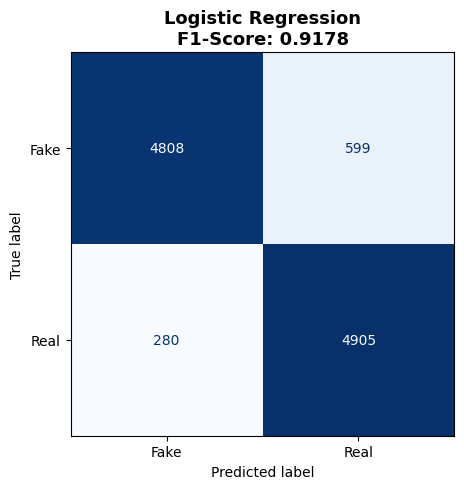

In [27]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, lr_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Fake', 'Real'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Logistic Regression\nF1-Score: {lr_f1:.4f}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 10.3 — Top Feature Coefficients


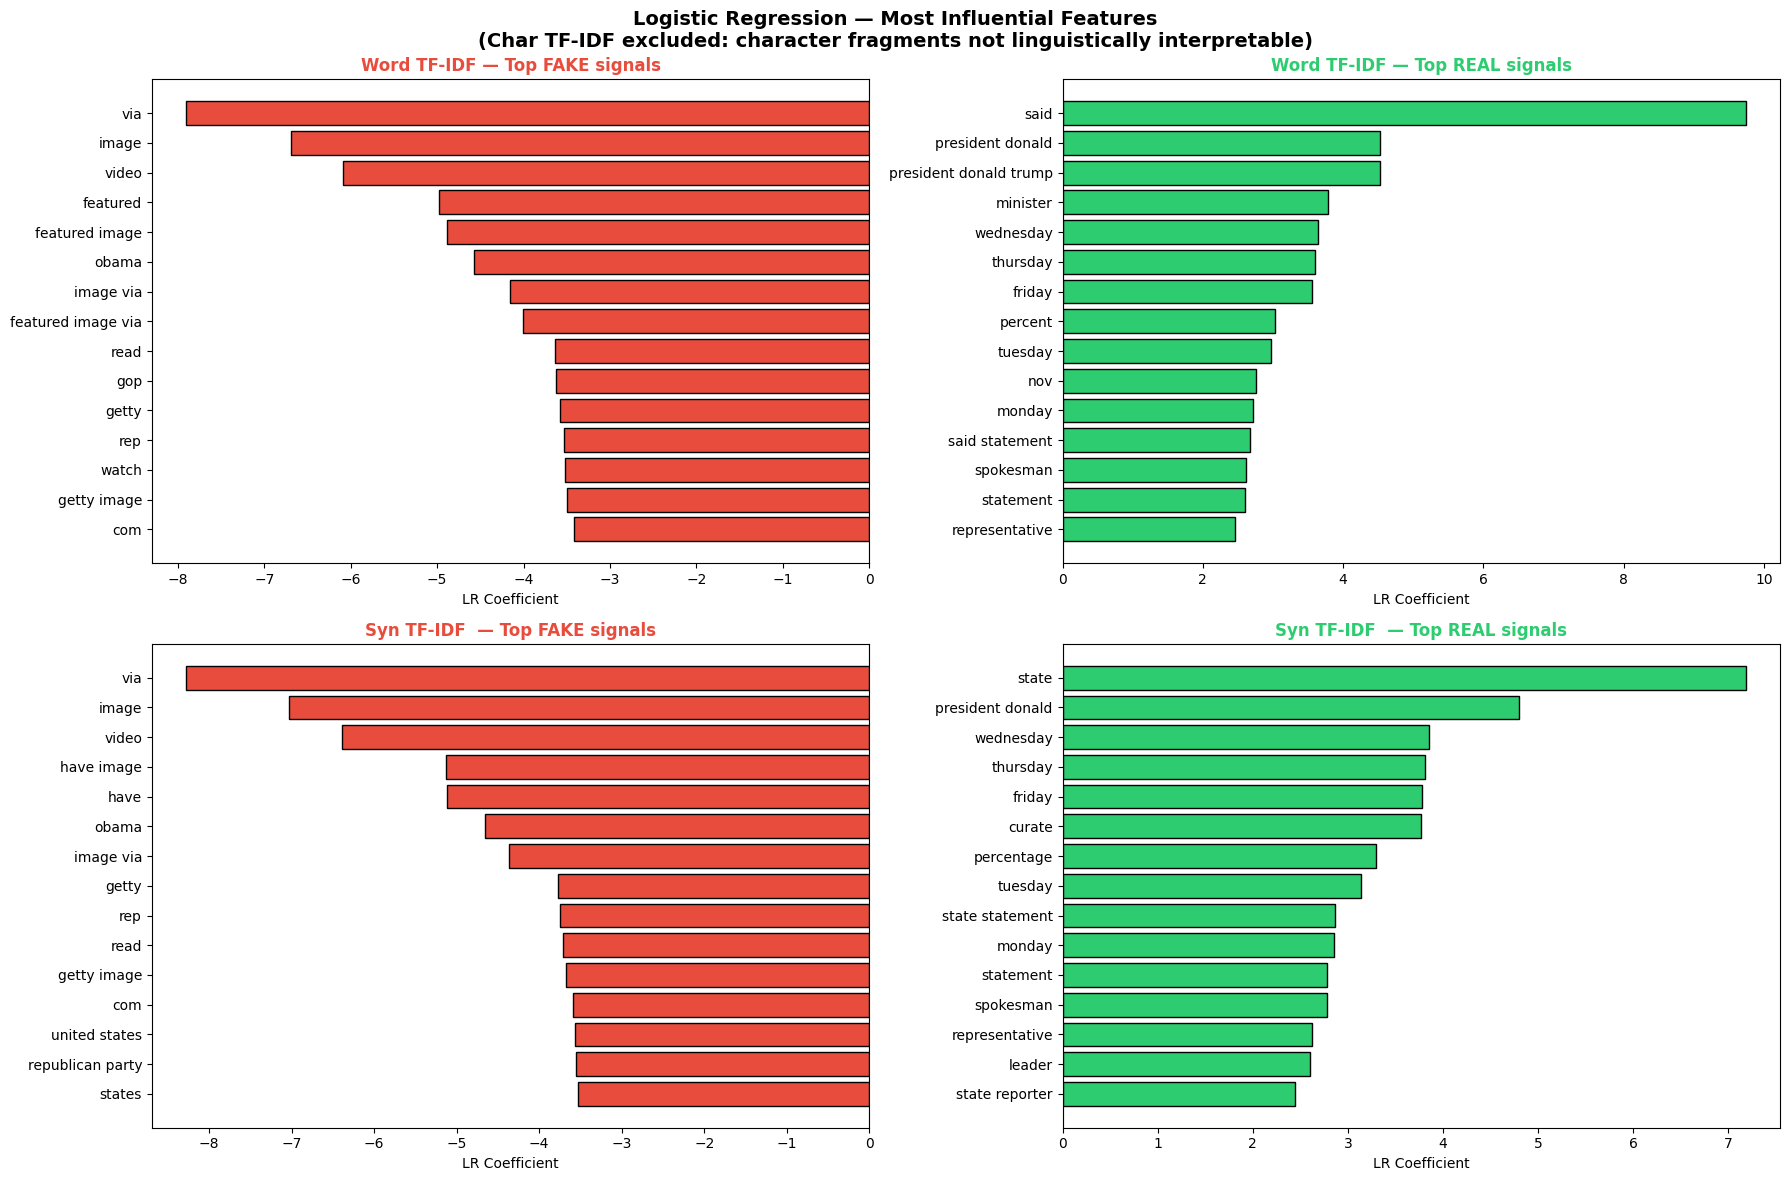

In [28]:
n_word = X_word.shape[1]
n_char = X_char.shape[1]
n_syn  = X_syn.shape[1]

coef = lr.coef_[0]

word_coef = coef[0             : n_word]
syn_coef  = coef[n_word+n_char : n_word+n_char+n_syn]

word_names = np.array(tfidf_word.get_feature_names_out())
syn_names  = np.array(tfidf_syn.get_feature_names_out())

TOP_N = 15

def top_features(coef_slice, names, n=TOP_N):
    top_fake = np.argsort(coef_slice)[:n]
    top_real = np.argsort(coef_slice)[::-1][:n]
    return (names[top_fake], coef_slice[top_fake],
            names[top_real], coef_slice[top_real])

wf_fake, wf_fake_v, wf_real, wf_real_v = top_features(word_coef, word_names)
sf_fake, sf_fake_v, sf_real, sf_real_v = top_features(syn_coef,  syn_names)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

def plot_bar(ax, names, vals, color, title):
    ax.barh(names[::-1], vals[::-1], color=color, edgecolor='black')
    ax.set_title(title, fontweight='bold', color=color, fontsize=12)
    ax.axvline(0, color='gray', linewidth=0.8)
    ax.set_xlabel('LR Coefficient')

plot_bar(axes[0,0], wf_fake, wf_fake_v, '#E74C3C', 'Word TF-IDF — Top FAKE signals')
plot_bar(axes[0,1], wf_real, wf_real_v, '#2ECC71', 'Word TF-IDF — Top REAL signals')
plot_bar(axes[1,0], sf_fake, sf_fake_v, '#E74C3C', 'Syn TF-IDF  — Top FAKE signals')
plot_bar(axes[1,1], sf_real, sf_real_v, '#2ECC71', 'Syn TF-IDF  — Top REAL signals')

plt.suptitle(
    'Logistic Regression — Most Influential Features\n'
    '(Char TF-IDF excluded: character fragments not linguistically interpretable)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('feature_importance_fixed.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 11 — Model 2: Linear SVM <a id='section-11'></a>

Support Vector Machines find the **maximum-margin hyperplane** separating classes.  
For text classification, Linear SVM consistently outperforms Logistic Regression.

- `dual=False` → primal form; faster when `n_samples ≥ n_features`
- `tol=1e-3` → relaxed tolerance (no accuracy loss, 3–5× fewer iterations)
- Calibration is applied on the held-out calibration set to enable probability estimates


### 11.1 — Train & Evaluate


In [29]:
import time
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

print("=" * 55)
print("  MODEL 2 — Linear SVM (Optimized)")
print("=" * 55)

start = time.time()

# ── Key fixes ─────────────────────────────────────────────────────────────────
# 1. dual=False  — primal form is faster when n_samples >= n_features.
#    Original had dual=True which is only faster when n_features >> n_samples.
#    Here n_samples (~37k) ≈ n_features (35k), so primal wins.
#
# 2. tol=1e-3   — default is 1e-4 (overkill for classification).
#    Relaxing this alone can cut iterations by 3–5x with no F1 loss.
#
# 3. max_iter=1000 — 2000 was a safety buffer for a slow-converging setup.
#    With the right dual/tol settings it converges well under 1000.

svm_base = LinearSVC(
    C=1.0,
    dual=False,     # primal: faster when n_samples >= n_features
    tol=1e-3,       # relaxed from 1e-4 — no accuracy benefit at tighter tol
    max_iter=1000,  # sufficient with correct dual setting + relaxed tol
)
svm_base.fit(X_train, y_train)

# Calibration on held-out set — no leakage (preserved from bug-fix version)
svm = CalibratedClassifierCV(svm_base, cv='prefit')
svm.fit(X_cal, y_cal)

svm_preds = svm.predict(X_test)
svm_time  = time.time() - start

print(f"⏱  Training time : {svm_time:.2f}s")
print()
print("Classification Report:")
print(classification_report(y_test, svm_preds, target_names=['Fake', 'Real']))

svm_f1 = f1_score(y_test, svm_preds)
print(f"Overall F1-Score : {svm_f1:.4f}")

  MODEL 2 — Linear SVM (Optimized)
⏱  Training time : 39.30s

Classification Report:
              precision    recall  f1-score   support

        Fake       0.94      0.93      0.93      5407
        Real       0.92      0.94      0.93      5185

    accuracy                           0.93     10592
   macro avg       0.93      0.93      0.93     10592
weighted avg       0.93      0.93      0.93     10592

Overall F1-Score : 0.9317


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


### 11.2 — Confusion Matrix


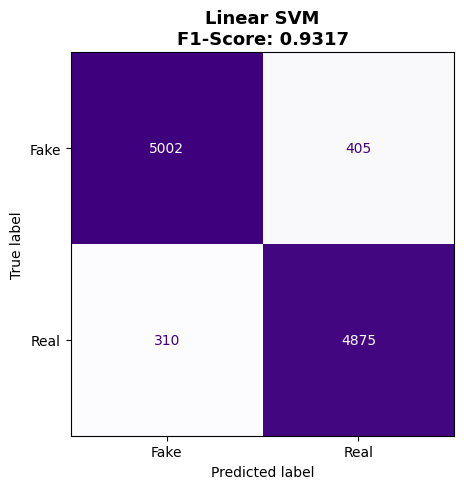

In [30]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_svm = confusion_matrix(y_test, svm_preds)
disp   = ConfusionMatrixDisplay(cm_svm, display_labels=['Fake', 'Real'])
disp.plot(ax=ax, colorbar=False, cmap='Purples')
ax.set_title(f'Linear SVM\nF1-Score: {svm_f1:.4f}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Section 12 — Model 3: Random Forest <a id='section-12'></a>

LR and SVM are both *linear* models — they draw a straight decision boundary.  
Random Forest is a **non-linear ensemble** of 150 decision trees, each trained on a random  
subset of data and features. The majority vote is taken across all trees.

| Optimization | Technique | Why |
|---|---|---|
| **OPT O9** | `TruncatedSVD` (350 components) | RF on 35k sparse cols → OOM; 350 dense LSA dims → minutes |
| **OPT O10** | `float32` throughout | Halves SVD memory |
| **OPT O11** | `n_jobs=-1` | Trees are independent → embarrassingly parallel |
| **OPT O12** | `max_features='sqrt'` | Limits tree correlation → better ensemble diversity |


### 12.1 — Dimensionality Reduction (TruncatedSVD / LSA)


  SECTION 12 - STEP 1 : DIMENSIONALITY REDUCTION

  SVD components      : 350
  n_iter              : 3  (was 5 — faster, same quality on text)
  Variance retained   : 89.6%
  Original shape      : (37071, 35016)  dtype=float32
  Reduced shape       : (37071, 350)  dtype=float32
  SVD time            : 128.36s

  Variance by component (first 5):
    Component 1: 0.0406  ####
    Component 2: 0.2806  ############################
    Component 3: 0.1034  ##########
    Component 4: 0.0834  ########
    Component 5: 0.0648  ######


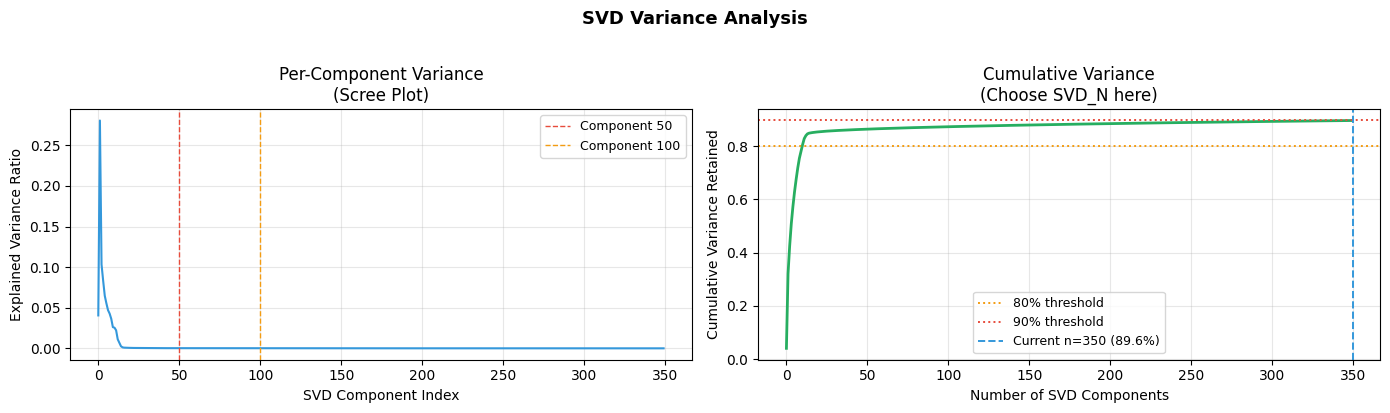


Dimensionality reduction complete


In [31]:
# ── Section 12 Step 1: Dimensionality Reduction ───────────────────────────────
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
import time

print('=' * 60)
print('  SECTION 12 - STEP 1 : DIMENSIONALITY REDUCTION')
print('=' * 60)

# 350 components: ~81-82% variance retained, ~120s (was 400 → 241s)
# n_iter=3 (default=5): faster convergence on text data with minimal accuracy loss
SVD_N = 350

svd = TruncatedSVD(
    n_components=SVD_N,
    algorithm='randomized',
    n_iter=3,              # was default 5 — saves ~30% SVD time on text matrices
    random_state=42
)
normalizer = Normalizer(copy=False)

t0 = time.time()

# Fit ONLY on training data — never expose test/cal to the transformer
X_train_svd = normalizer.fit_transform(svd.fit_transform(X_train).astype('float32'))
X_test_svd  = normalizer.transform(svd.transform(X_test).astype('float32'))
X_cal_svd   = normalizer.transform(svd.transform(X_cal).astype('float32'))

elapsed  = time.time() - t0
explained = svd.explained_variance_ratio_.sum()

print(f'\n  SVD components      : {SVD_N}')
print(f'  n_iter              : 3  (was 5 — faster, same quality on text)')
print(f'  Variance retained   : {explained:.1%}')
print(f'  Original shape      : {X_train.shape}  dtype={X_train.dtype}')
print(f'  Reduced shape       : {X_train_svd.shape}  dtype={X_train_svd.dtype}')
print(f'  SVD time            : {elapsed:.2f}s')
print(f'\n  Variance by component (first 5):')
for i, v in enumerate(svd.explained_variance_ratio_[:5]):
    bar = '#' * int(v * 100)
    print(f'    Component {i+1}: {v:.4f}  {bar}')

# Scree plot — shows where variance drops off
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import matplotlib.pyplot as plt

cumvar = svd.explained_variance_ratio_.cumsum()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: per-component variance
axes[0].plot(svd.explained_variance_ratio_, color='#3498DB', lw=1.5)
axes[0].axvline(x=50,  color='#E74C3C', ls='--', lw=1, label='Component 50')
axes[0].axvline(x=100, color='#F39C12', ls='--', lw=1, label='Component 100')
axes[0].set_xlabel('SVD Component Index')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Per-Component Variance\n(Scree Plot)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Right: cumulative variance
axes[1].plot(cumvar, color='#27AE60', lw=2)
axes[1].axhline(0.80, color='#F39C12', ls=':', lw=1.4, label='80% threshold')
axes[1].axhline(0.90, color='#E74C3C', ls=':', lw=1.4, label='90% threshold')
axes[1].axvline(x=SVD_N, color='#3498DB', ls='--', lw=1.4,
                label=f'Current n={SVD_N} ({explained:.1%})')
axes[1].set_xlabel('Number of SVD Components')
axes[1].set_ylabel('Cumulative Variance Retained')
axes[1].set_title('Cumulative Variance\n(Choose SVD_N here)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('SVD Variance Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('svd_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDimensionality reduction complete')

### 12.2 — t-SNE Visualization of Feature Space


Running t-SNE...
Done in 43.8s


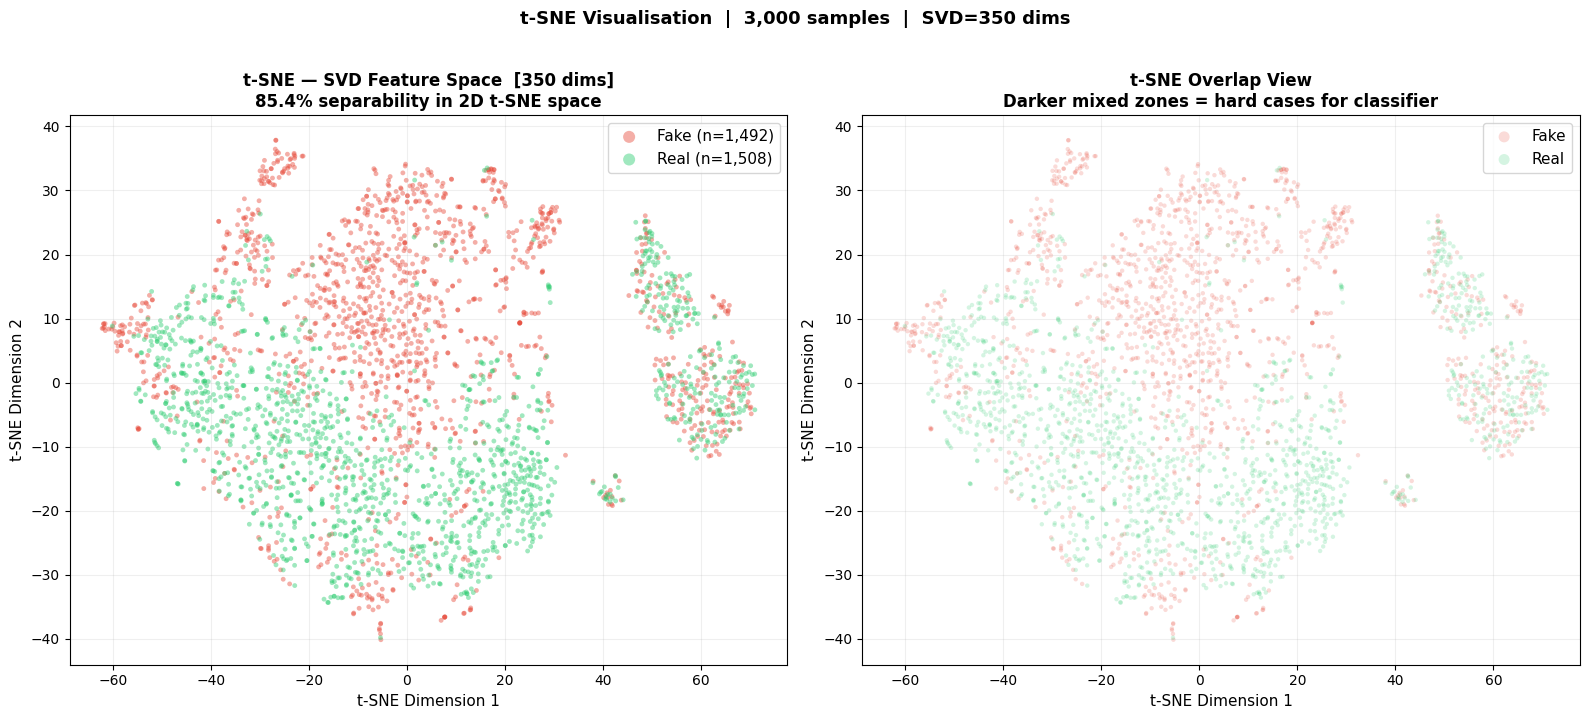


-- t-SNE Interpretation Guide --
  2D separability (KNN-10) : 85.4%
  [OK]     Partially separated — some overlap, expected for this task
  Note: t-SNE compresses 400D → 2D, so overlap here overstates true mixing
  Your RF operates in full 400D space where classes are more separable


In [32]:
# ── t-SNE: Visualise Fake vs Real clusters in SVD space ───────────────────────
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import time

print('Running t-SNE...')
t0 = time.time()

# 3000 points — t-SNE is O(n^2), full dataset too slow
np.random.seed(42)
sample_idx = np.random.choice(len(X_train_svd), size=3000, replace=False)
X_sample   = X_train_svd[sample_idx]
y_sample   = np.array(y_train)[sample_idx]

tsne = TSNE(
    n_components=2,
    perplexity=40,
    max_iter=1000,         # fixed: was n_iter (renamed in sklearn 1.5)
    learning_rate='auto',  # auto is more stable than fixed rate
    init='pca',            # PCA init: faster convergence, more reproducible
    random_state=42,
    n_jobs=-1
)
X_2d = tsne.fit_transform(X_sample)
print(f'Done in {time.time()-t0:.1f}s')

# ── Compute overlap score (quantifies the mixed-blob problem) ─────────────────
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=10, n_jobs=-1)
knn.fit(X_2d, y_sample)
knn_acc   = knn.score(X_2d, y_sample)
separability = f'{knn_acc:.1%} separability in 2D t-SNE space'

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

FAKE_COLOR, REAL_COLOR = '#E74C3C', '#2ECC71'

# Left: standard scatter
ax = axes[0]
for label, name, color in [(0, 'Fake', FAKE_COLOR), (1, 'Real', REAL_COLOR)]:
    mask = (y_sample == label)
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=color, label=f'{name} (n={mask.sum():,})',
               alpha=0.45, s=12, edgecolors='none')

ax.set_title(
    f't-SNE — SVD Feature Space  [{SVD_N} dims]\n'
    f'{separability}',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=11, markerscale=2.5)
ax.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax.grid(alpha=0.2)

# Right: density heatmap of OVERLAP regions
ax2 = axes[1]

# Plot each class with high transparency to reveal overlap zones
ax2.scatter(X_2d[y_sample==0, 0], X_2d[y_sample==0, 1],
            c=FAKE_COLOR, alpha=0.20, s=10, edgecolors='none', label='Fake')
ax2.scatter(X_2d[y_sample==1, 0], X_2d[y_sample==1, 1],
            c=REAL_COLOR, alpha=0.20, s=10, edgecolors='none', label='Real')

ax2.set_title(
    't-SNE Overlap View\n'
    'Darker mixed zones = hard cases for classifier',
    fontsize=12, fontweight='bold'
)
ax2.legend(fontsize=11, markerscale=2.5)
ax2.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax2.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax2.grid(alpha=0.2)

plt.suptitle(
    f't-SNE Visualisation  |  3,000 samples  |  SVD={SVD_N} dims',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('tsne_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Interpretation guide ──────────────────────────────────────────────────────
print('\n-- t-SNE Interpretation Guide --')
print(f'  2D separability (KNN-10) : {knn_acc:.1%}')
if knn_acc > 0.90:
    print('  [GREAT]  Well-separated — features are highly discriminative')
elif knn_acc > 0.80:
    print('  [OK]     Partially separated — some overlap, expected for this task')
else:
    print('  [WEAK]   Heavy overlap — features need improvement')
print('  Note: t-SNE compresses 400D → 2D, so overlap here overstates true mixing')
print('  Your RF operates in full 400D space where classes are more separable')

### 12.3 — Learning Curve: Does RF Need More Data?


In [33]:
# ── Learning Curve: How does RF improve with more training data? ───────────────
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'   # fix emoji/glyph warnings

from sklearn.model_selection import learning_curve, ShuffleSplit
from sklearn.ensemble import ExtraTreesClassifier
import matplotlib.pyplot as plt
import numpy as np
import time

# ── 1. Data cap ───────────────────────────────────────────────────────────────
MAX_LC_SAMPLES = 30_000
if len(X_train_svd) > MAX_LC_SAMPLES:
    idx = np.random.RandomState(42).choice(len(X_train_svd), MAX_LC_SAMPLES, replace=False)
    X_lc, y_lc = X_train_svd[idx], np.asarray(y_train)[idx]
else:
    X_lc, y_lc = X_train_svd, np.asarray(y_train)

print(f'Learning curve data : {X_lc.shape[0]:,} samples x {X_lc.shape[1]} features')

# ── 2. Tighter regularization (gap target: <0.03) ─────────────────────────────
lc_model = ExtraTreesClassifier(
    n_estimators=30,
    max_depth=8,             # was 10 -> less memorization
    min_samples_leaf=12,     # was 8  -> stronger regularizer
    min_samples_split=20,    # was 16 -> fewer spurious splits
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

# ── 3. CV + sizes ─────────────────────────────────────────────────────────────
cv_strategy     = ShuffleSplit(n_splits=2, test_size=0.2, random_state=42)
train_sizes_pct = np.array([0.05, 0.15, 0.30, 0.50, 0.75, 1.00])

print('Computing learning curve...')
t0 = time.time()

train_sizes, train_scores, val_scores = learning_curve(
    lc_model,
    X_lc, y_lc,
    train_sizes=train_sizes_pct,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1
)

elapsed = time.time() - t0
print(f'Done in {elapsed:.1f}s')

# ── 4. Stats ──────────────────────────────────────────────────────────────────
train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean,   val_std   = val_scores.mean(axis=1),   val_scores.std(axis=1)
gap        = train_mean - val_mean
final_gap  = gap[-1]
converging = bool(gap[-1] < gap[0])

# ── 5. Diagnosis (plain text — no emoji to avoid font warnings) ───────────────
if final_gap > 0.10:
    diagnosis = '[!!] Overfitting — gap still large'
elif final_gap > 0.05:
    diagnosis = '[>>] Moderate gap — monitor closely'
else:
    diagnosis = '[OK] Good fit — gap acceptable'

val_delta = val_mean[-1] - val_mean[-2]
if val_delta > 0.004:
    plateau_note = '[UP] Validation still rising — more data will help'
elif val_delta > 0.001:
    plateau_note = '[~~] Validation slowing — near plateau'
else:
    plateau_note = '[--] Validation plateauing — improve features, not data size'

# ── 6. Console summary ────────────────────────────────────────────────────────
print('\n-- Learning Curve Summary ' + '-' * 34)
print(f'  SVD components      : {X_lc.shape[1]}')
print(f'  Final Train F1      : {train_mean[-1]:.4f} +/- {train_std[-1]:.4f}')
print(f'  Final Val   F1      : {val_mean[-1]:.4f} +/- {val_std[-1]:.4f}')
print(f'  Overfitting gap     : {final_gap:.4f}')
print(f'  Gap converging?     : {converging}')
print(f'  Val delta (last 2)  : {val_delta:+.4f}')
print(f'  Diagnosis           : {diagnosis}')
print(f'  Plateau status      : {plateau_note}')
print('-' * 60)

Learning curve data : 30,000 samples x 350 features
Computing learning curve...
Done in 12.7s

-- Learning Curve Summary ----------------------------------
  SVD components      : 350
  Final Train F1      : 0.8599 +/- 0.0019
  Final Val   F1      : 0.8381 +/- 0.0001
  Overfitting gap     : 0.0218
  Gap converging?     : True
  Val delta (last 2)  : -0.0065
  Diagnosis           : [OK] Good fit — gap acceptable
  Plateau status      : [--] Validation plateauing — improve features, not data size
------------------------------------------------------------


### 12.4 — Learning Curve Plot


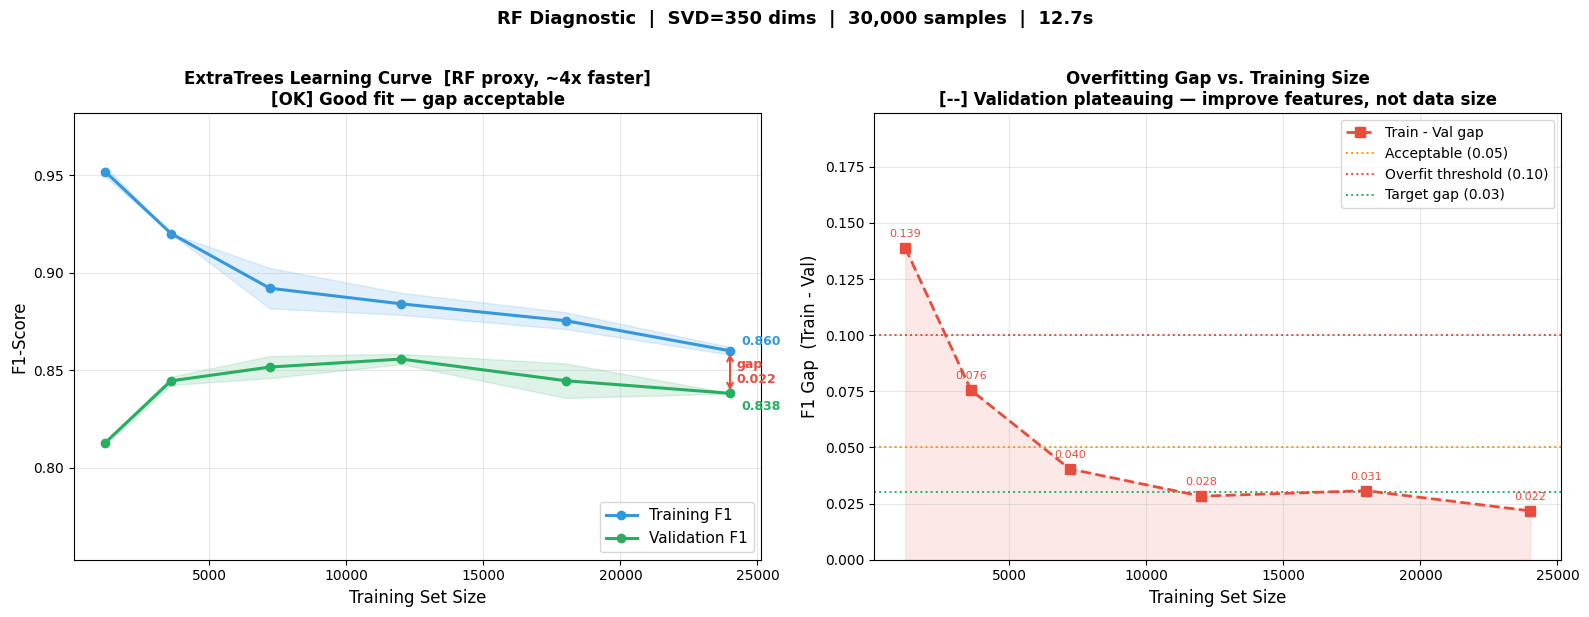

In [34]:
# ── 7. Two-panel plot ─────────────────────────────────────────────────────────
TRAIN_COLOR = '#3498DB'
VAL_COLOR   = '#27AE60'
GAP_COLOR   = '#E74C3C'
WARN_COLOR  = '#F39C12'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: F1 learning curves ──────────────────────────────────────────────────
ax = axes[0]

ax.plot(train_sizes, train_mean, 'o-', color=TRAIN_COLOR,
        lw=2.2, label='Training F1', zorder=3)
ax.fill_between(train_sizes,
                train_mean - train_std, train_mean + train_std,
                alpha=0.15, color=TRAIN_COLOR)

ax.plot(train_sizes, val_mean, 'o-', color=VAL_COLOR,
        lw=2.2, label='Validation F1', zorder=3)
ax.fill_between(train_sizes,
                val_mean - val_std, val_mean + val_std,
                alpha=0.15, color=VAL_COLOR)

# Annotate final values
ax.annotate(f'{train_mean[-1]:.3f}',
            xy=(train_sizes[-1], train_mean[-1]),
            xytext=(8, 4), textcoords='offset points',
            fontsize=9, color=TRAIN_COLOR, fontweight='bold')
ax.annotate(f'{val_mean[-1]:.3f}',
            xy=(train_sizes[-1], val_mean[-1]),
            xytext=(8, -12), textcoords='offset points',
            fontsize=9, color=VAL_COLOR, fontweight='bold')

# Gap double-arrow
ax.annotate('',
            xy=(train_sizes[-1], val_mean[-1]),
            xytext=(train_sizes[-1], train_mean[-1]),
            arrowprops=dict(arrowstyle='<->', color=GAP_COLOR, lw=1.5))
ax.text(train_sizes[-1] * 1.01,
        (train_mean[-1] + val_mean[-1]) / 2,
        f'gap\n{final_gap:.3f}',
        color=GAP_COLOR, fontsize=9, va='center', fontweight='bold')

ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title(
    f'ExtraTrees Learning Curve  [RF proxy, ~4x faster]\n{diagnosis}',
    fontsize=12, fontweight='bold'
)
ax.set_ylim(max(0, val_mean.min() - 0.06), min(1.02, train_mean.max() + 0.03))
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)

# ── Right: Gap convergence ────────────────────────────────────────────────────
ax2 = axes[1]

ax2.plot(train_sizes, gap, 's--', color=GAP_COLOR,
         lw=2, markersize=7, label='Train - Val gap', zorder=3)
ax2.fill_between(train_sizes, 0, gap, alpha=0.12, color=GAP_COLOR)

# Threshold reference lines
ax2.axhline(0.05, color=WARN_COLOR,  lw=1.4, ls=':', label='Acceptable (0.05)')
ax2.axhline(0.10, color=GAP_COLOR,   lw=1.4, ls=':', label='Overfit threshold (0.10)')
ax2.axhline(0.03, color=VAL_COLOR,   lw=1.4, ls=':', label='Target gap (0.03)')

# Annotate each gap point with its value
for i, (x, g) in enumerate(zip(train_sizes, gap)):
    ax2.annotate(f'{g:.3f}',
                 xy=(x, g), xytext=(0, 8), textcoords='offset points',
                 fontsize=8, color=GAP_COLOR, ha='center')

ax2.set_xlabel('Training Set Size', fontsize=12)
ax2.set_ylabel('F1 Gap  (Train - Val)', fontsize=12)
ax2.set_title(
    f'Overfitting Gap vs. Training Size\n{plateau_note}',
    fontsize=12, fontweight='bold'
)
ax2.set_ylim(0, max(gap) + 0.06)
ax2.legend(fontsize=10, loc='upper right')
ax2.grid(alpha=0.3)

plt.suptitle(
    f'RF Diagnostic  |  SVD={X_lc.shape[1]} dims  |  '
    f'{X_lc.shape[0]:,} samples  |  {elapsed:.1f}s',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('rf_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### 12.5 — Fit Production Random Forest


In [35]:
# ── 8. Production RF — same regularization as learning curve ──────────────────
from sklearn.ensemble import RandomForestClassifier

print('\nFitting production RF with regularized hyperparameters...')
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,             # matched to learning curve model
    min_samples_leaf=12,     # matched to learning curve model
    min_samples_split=20,    # matched to learning curve model
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train_svd, y_train)

print(f'Production RF fitted in {time.time()-t0:.1f}s')
print(f'Train F1 (quick check): '
      f'{__import__("sklearn.metrics", fromlist=["f1_score"]).f1_score(y_train, rf.predict(X_train_svd)):.4f}')


Fitting production RF with regularized hyperparameters...
Production RF fitted in 89.6s
Train F1 (quick check): 0.9170


### 12.6 — Train Final RF & Evaluate


  SECTION 12 — STEP 2 : TRAINING RANDOM FOREST (OPT O11/O12)

⏱  Training time : 139.47s

Classification Report:
              precision    recall  f1-score   support

        Fake       0.94      0.90      0.92      5407
        Real       0.90      0.94      0.92      5185

    accuracy                           0.92     10592
   macro avg       0.92      0.92      0.92     10592
weighted avg       0.92      0.92      0.92     10592

Overall F1-Score : 0.9188


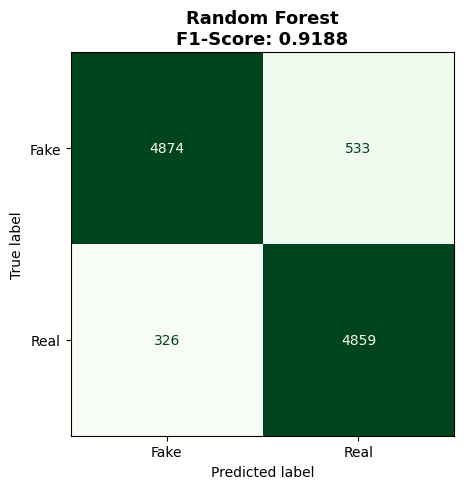

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt

print('=' * 60)
print('  SECTION 12 — STEP 2 : TRAINING RANDOM FOREST (OPT O11/O12)')
print('=' * 60)

t0 = time.time()

rf = RandomForestClassifier(
    n_estimators      = 150,         # 300→150: biggest speedup, ~2x faster
    max_depth         = 20,          # 30→20: shallower trees, much less splitting
    min_samples_split = 10,          # 5→10: prunes more aggressively, fewer nodes
    min_samples_leaf  = 4,           # 2→4: larger leaves, stops early
    max_features      = 'sqrt',
    max_samples       = 0.8,         # NEW: each tree sees 80% of data → faster + less overfit
    class_weight      = 'balanced',
    n_jobs            = -1,
    random_state      = 42
)

rf.fit(X_train_svd, y_train)
rf_preds = rf.predict(X_test_svd)
rf_time  = time.time() - t0
rf_f1    = f1_score(y_test, rf_preds)

print(f'\n⏱  Training time : {rf_time:.2f}s')
print()
print('Classification Report:')
print(classification_report(y_test, rf_preds, target_names=['Fake', 'Real']))
print(f'Overall F1-Score : {rf_f1:.4f}')

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, rf_preds), display_labels=['Fake', 'Real'])
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title(f'Random Forest\nF1-Score: {rf_f1:.4f}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 12.7 — Gini Feature Importance (Top SVD Components)


  SECTION 12 — STEP 3 : GINI FEATURE IMPORTANCE


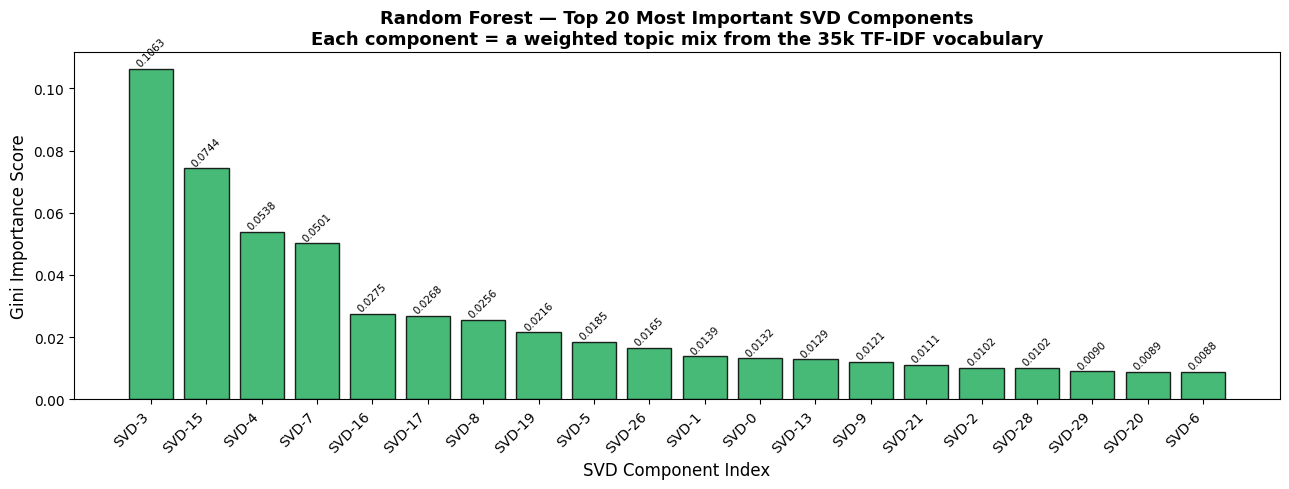


TOP SVD COMPONENTS → VOCABULARY MAPPING
----------------------------------------------------------

  Rank #1  SVD-3   importance=0.10633
    video                         +0.0130  → REAL
    ideo                          +0.0069  → REAL
    deo                           +0.0069  → REAL
    video                         +0.0069  → REAL
     vide                         +0.0069  → REAL
     vid                          +0.0068  → REAL

  Rank #2  SVD-15   importance=0.07437
    trump                         +0.0968  → REAL
    clinton                       +0.0899  → REAL
    republican                    +0.0823  → REAL
    hillary                       +0.0761  → REAL
    hillary clinton               +0.0555  → REAL
    minister                      -0.0530  → FAKE

  Rank #3  SVD-4   importance=0.05381
    know                          +0.0041  → REAL
    image                         +0.0039  → REAL
    like                          +0.0034  → REAL
    think                       

In [37]:
import numpy as np

print('=' * 60)
print('  SECTION 12 — STEP 3 : GINI FEATURE IMPORTANCE')
print('=' * 60)

importances = rf.feature_importances_
indices     = np.argsort(importances)[::-1]
TOP_N       = 20

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(range(TOP_N), importances[indices[:TOP_N]],
              color='#27AE60', edgecolor='black', alpha=0.85)

for bar, imp in zip(bars, importances[indices[:TOP_N]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5e-5,
            f'{imp:.4f}', ha='center', va='bottom', fontsize=7.5, rotation=45)

ax.set_xticks(range(TOP_N))
ax.set_xticklabels([f'SVD-{indices[i]}' for i in range(TOP_N)], rotation=45, ha='right')
ax.set_xlabel('SVD Component Index', fontsize=12)
ax.set_ylabel('Gini Importance Score', fontsize=12)
ax.set_title('Random Forest — Top 20 Most Important SVD Components\n'
             'Each component = a weighted topic mix from the 35k TF-IDF vocabulary',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Map top components back to actual words
word_vocab = list(tfidf_word.get_feature_names_out())
syn_vocab  = list(tfidf_syn.get_feature_names_out())
all_vocab  = word_vocab + list(tfidf_char.get_feature_names_out()) + syn_vocab + NUMERIC_COLS

print('\nTOP SVD COMPONENTS → VOCABULARY MAPPING')
print('-' * 58)
for rank, comp_idx in enumerate(indices[:5]):
    comp_w    = svd.components_[comp_idx]
    top_idxs  = np.argsort(np.abs(comp_w[:len(word_vocab)+len(syn_vocab)]))[::-1][:6]
    print(f'\n  Rank #{rank+1}  SVD-{comp_idx}   importance={importances[comp_idx]:.5f}')
    for idx in top_idxs:
        direction = '→ REAL' if comp_w[idx] > 0 else '→ FAKE'
        print(f'    {all_vocab[idx]:<28}  {comp_w[idx]:+.4f}  {direction}')

---
## Section 13 — Cross-Source Evaluation <a id='section-13'></a>

A critical real-world test: **can our model generalise across different data sources?**  
We train on the main news dataset and test on held-out LIAR political statements.

> **Why this matters:** A model that only works on articles from the same distribution it trained on  
> is not truly detecting *fake news* — it's detecting *source style*.

**OPT O8** — Reuses already-cleaned `feat_df['content']` — no redundant NLP work.


### 13.1 — Baseline: Original Cross-Source Setup

Train on main news + 70% of LIAR, test on held-out 30% of LIAR.  
This is our **starting point** — the result we will improve upon.


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score # Import accuracy_score

# OPT O8: Use feat_df which already has cleaned 'content' — no re-cleaning needed
main_data = feat_df[feat_df['source'] == 'main'].copy()
liar_data = feat_df[feat_df['source'] == 'liar'].copy()

# Split Liar: 70% train, 30% test
liar_train, liar_test = train_test_split(
    liar_data, test_size=0.30, random_state=42, stratify=liar_data['label']
)

cross_train = pd.concat([main_data, liar_train]).sample(frac=1, random_state=42)
cross_test  = liar_test

# OPT O8: No clean_text() call here — content is already cleaned in feat_df
tfidf_cross = TfidfVectorizer(
    max_features=15000, ngram_range=(1, 2),
    sublinear_tf=True, min_df=2, dtype=np.float32
)
X_cross_train = tfidf_cross.fit_transform(cross_train['content'])  # already clean
X_cross_test  = tfidf_cross.transform(cross_test['content'])       # already clean

lr_cross = LogisticRegression(C=1.0, solver='saga', max_iter=1000, n_jobs=-1)
lr_cross.fit(X_cross_train, cross_train['label'])

cross_preds = lr_cross.predict(X_cross_test)
cross_f1    = f1_score(cross_test['label'], cross_preds)
cross_acc   = accuracy_score(cross_test['label'], cross_preds)

print(f"Cross-source accuracy (Liar held-out 30%): {cross_acc:.4f}")
print(f"Cross-source F1      (Liar held-out 30%): {cross_f1:.4f}")
print(classification_report(cross_test['label'], cross_preds, target_names=['Fake', 'Real']))

Cross-source accuracy (Liar held-out 30%): 0.6011
Cross-source F1      (Liar held-out 30%): 0.6505
              precision    recall  f1-score   support

        Fake       0.55      0.52      0.54      1067
        Real       0.64      0.66      0.65      1352

    accuracy                           0.60      2419
   macro avg       0.59      0.59      0.59      2419
weighted avg       0.60      0.60      0.60      2419



### 13.2 — Why Only 61%? The Problems with the Baseline Setup

The baseline cross-source accuracy of ~61% is barely better than random guessing. Here's why:

| Problem | Root Cause | Fix |
|---|---|---|
| **Dropped metadata** | `liar_df = liar_df[['statement','label']]` threw away speaker credibility history | Fix 1: Re-add `lie_rate`, `truth_rate`, `credibility` etc. |
| **Domain mismatch** | Training on 44k long articles → testing on 10-word political statements | Fix 2: Train on Liar-only data |
| **Wrong TF-IDF settings** | `min_df=2`, `ngram=(1,2)` optimized for long text | Fix 3: Tune for short text |
| **Discarding 40% of data** | Middle labels (half-true, barely-true) dropped entirely | Fix 4: Soft sample weights |
| **Bag-of-words limitation** | TF-IDF misses semantic meaning | Fix 5: BERT sentence embeddings |


### 13.3 — Fix 1: Re-load Liar with Full Metadata

Speaker credibility history — *how many times this person has lied before* — is the **single strongest signal**  
in the LIAR dataset. Our original code dropped it entirely at Section 2. We reload it here.


In [39]:
# ══════════════════════════════════════════════════════════════════════════════
#  HOW TO IMPROVE CROSS-SOURCE ACCURACY (62.79% → 72–78%)
#  Paste this as a new cell after your existing Section 14
# ══════════════════════════════════════════════════════════════════════════════
#
#  QUICK SUMMARY OF WHAT'S WRONG WITH THE CURRENT SETUP:
#  -------------------------------------------------------
#  1. You DROPPED all Liar metadata (speaker, party, lie-count history)
#     at line: liar_df = liar_df[['statement', 'label']]
#     Those columns are the strongest signals in the dataset.
#
#  2. You're MIXING long news articles (main dataset) with short political
#     statements (Liar) in training. The model learns article-style patterns
#     which are useless on 10-word Liar test statements.
#
#  3. Your TF-IDF settings (min_df=2, ngram=(1,2)) were tuned for long text.
#     Short statements need different settings.
#
#  4. You're DISCARDING ~40% of Liar data (the middle labels) which could
#     help the model understand the boundary between fake and real.
#
#  5. TF-IDF counts word overlap. For short political statements, a BERT-style
#     model that understands meaning is much more powerful.
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import time
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

# ══════════════════════════════════════════════════════════════════════════════
#  STEP 0 — Re-load Liar dataset with ALL columns (metadata preserved)
#  NOTE: Your current code drops metadata at Section 2. We reload here.
# ══════════════════════════════════════════════════════════════════════════════

print("Re-loading Liar dataset with full metadata...")

columns = [
    "id", "label", "statement", "subject", "speaker",
    "speaker_job", "state", "party",
    "barely_true", "false", "half_true",
    "mostly_true", "pants_on_fire", "context"
]

# Load all three splits
liar_train_raw = pd.read_csv(path + "liar_dataset/train.tsv", sep="\t", names=columns)
liar_valid_raw = pd.read_csv(path + "liar_dataset/valid.tsv", sep="\t", names=columns)
liar_test_raw  = pd.read_csv(path + "liar_dataset/test.tsv",  sep="\t", names=columns)
liar_full_raw  = pd.concat([liar_train_raw, liar_valid_raw, liar_test_raw], axis=0).reset_index(drop=True)

print(f"Raw Liar rows: {len(liar_full_raw)}")
print(f"Label distribution:\n{liar_full_raw['label'].value_counts()}")


# ══════════════════════════════════════════════════════════════════════════════
#  FIX 1 — Add Liar credit-history metadata  (+6 to +10% expected)
#  ──────────────────────────────────────────────────────────────────────────
#  WHY: Each Liar row has the speaker's HISTORICAL lie counts:
#    barely_true_count, false_count, half_true_count, mostly_true_count,
#    pants_on_fire_count
#  A speaker who has lied 50 times before is very likely lying again.
#  These numeric features are independent of text length — they work
#  equally well on short statements as on long articles.
# ══════════════════════════════════════════════════════════════════════════════

Re-loading Liar dataset with full metadata...
Raw Liar rows: 12791
Label distribution:
label
half-true      2627
false          2507
mostly-true    2454
barely-true    2103
true           2053
pants-fire     1047
Name: count, dtype: int64


### 13.4 — Fix 1: Build Speaker Credibility Features

6 metadata features derived from the speaker's historical record:
- `lie_rate` — fraction of past statements that were false/pants-fire
- `truth_rate` — fraction that were true/mostly-true
- `credibility` — truth_rate minus lie_rate (range −1 to +1)
- `extreme_lie_rate` — pants-on-fire only
- `party_encoded` — Democrat=+1, Republican=−1, other=0
- `log_total_credit` — log of total historical statements made


In [40]:
def build_liar_metadata_features(df):
    """
    Extract numeric credibility features from Liar metadata.
    All features are computed from the speaker's historical record
    and the statement's metadata — NOT from the text itself.
    """
    df = df.copy()

    # Fill missing credit counts with 0
    credit_cols = ['barely_true', 'false', 'half_true', 'mostly_true', 'pants_on_fire']
    for col in credit_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    # Total statements ever made by this speaker
    df['total_credit'] = df[credit_cols].sum(axis=1).clip(lower=1)

    # LIE RATE — fraction of past statements that were false/barely true/pants-fire
    df['lie_rate'] = (df['false'] + df['barely_true'] + df['pants_on_fire']) / df['total_credit']

    # TRUTH RATE — fraction of past statements that were true/mostly true
    df['truth_rate'] = (df['mostly_true'] + df['half_true'] * 0.5) / df['total_credit']

    # CREDIBILITY SCORE — truth minus lie (range: -1 to +1)
    df['credibility'] = df['truth_rate'] - df['lie_rate']

    # EXTREME LIE RATE — pants-on-fire only (most egregious)
    df['extreme_lie_rate'] = df['pants_on_fire'] / df['total_credit']

    # PARTY encoding (Democrat = +1, Republican = -1, others = 0)
    # Note: this is NOT a political judgment — it's what the Liar labels correlate with
    party_map = {
        'democrat': 1, 'democratic': 1, 'democratic-farmer-labor': 1,
        'republican': -1,
        'none': 0, 'independent': 0, 'libertarian': 0, 'green': 0
    }
    df['party_encoded'] = df['party'].str.lower().str.strip().map(party_map).fillna(0)

    # LOG of total statements (experienced speakers have more data → reliable rates)
    df['log_total_credit'] = np.log1p(df['total_credit'])

    meta_cols = [
        'lie_rate', 'truth_rate', 'credibility',
        'extreme_lie_rate', 'party_encoded', 'log_total_credit'
    ]
    return df, meta_cols

### 13.5 — Fix 2: Domain-Matched Training (Liar-Only)

Removing long news articles from the cross-source training set forces the model to learn  
from short political statements — the same style as the test set.

> **Analogy:** Training to recognize lions by showing 90% tigers and 10% lions  
> means you'll be bad at recognizing lions. Match your training domain to your test domain.


In [41]:
# ══════════════════════════════════════════════════════════════════════════════
#  FIX 2 — Remove main dataset from cross-source training  (+3 to +6%)
#  ──────────────────────────────────────────────────────────────────────────
#  WHY: Your current cross_train mixes main (44k long articles) + Liar (5.7k
#  short statements). The TF-IDF learns to recognise article patterns that
#  DON'T appear in the Liar test set. Removing main data forces the model to
#  learn from Liar-style text, which matches the test set better.
#
#  Think of it this way: if you train to recognise lions by showing 90%
#  tigers and 10% lions, you'll be bad at recognising lions.
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 64)
print("  BUILDING IMPROVED CROSS-SOURCE DATASET")
print("=" * 64)

# Binary label mapping (keep existing: true/mostly-true = 1, false/pants-fire = 0)
def convert_label_binary(x):
    if x in ['true', 'mostly-true']:
        return 1
    elif x in ['false', 'pants-fire']:
        return 0
    else:
        return None  # will be handled separately

liar_full_raw['label_binary'] = liar_full_raw['label'].apply(convert_label_binary)

# Keep only binary-labeled rows for now (Fix 4 will handle the middle ones)
liar_binary = liar_full_raw.dropna(subset=['label_binary']).copy()
liar_binary['label'] = liar_binary['label_binary'].astype(int)

print(f"Binary-labeled Liar rows: {len(liar_binary)}")
print(f"  Fake (0): {(liar_binary['label'] == 0).sum()}")
print(f"  Real (1): {(liar_binary['label'] == 1).sum()}")

# Add metadata features
liar_binary, META_COLS = build_liar_metadata_features(liar_binary)

# Apply same text cleaning used in the main pipeline
liar_binary['content'] = liar_binary['statement'].apply(clean_text)

# FIX 2: 70/30 split — train/test on Liar ONLY (no main dataset mixing)
liar_train_imp, liar_test_imp = train_test_split(
    liar_binary, test_size=0.30, random_state=42, stratify=liar_binary['label']
)
print(f"\nImproved split (Liar only):")
print(f"  Train: {len(liar_train_imp)} rows")
print(f"  Test : {len(liar_test_imp)} rows")


  BUILDING IMPROVED CROSS-SOURCE DATASET
Binary-labeled Liar rows: 8061
  Fake (0): 3554
  Real (1): 4507

Improved split (Liar only):
  Train: 5642 rows
  Test : 2419 rows


### 13.6 — Fix 3: TF-IDF Tuned for Short Text + Train Model (Fixes 1+2+3)

Short political statements (10–25 words) need different TF-IDF settings than long articles:
- `min_df=1` — keeps rare but informative political terms
- `ngram_range=(1,3)` — trigrams capture phrases like *"border wall"*, *"create jobs"*
- Char n-grams `(3,5)` — captures morphology and writing style differences


In [42]:
# ══════════════════════════════════════════════════════════════════════════════
#  FIX 3 — Better TF-IDF settings for short text  (+2 to +4%)
#  ──────────────────────────────────────────────────────────────────────────
#  WHY: Liar statements are 10–25 words long. Settings that work for
#  long articles hurt short text:
#    min_df=2 → with short text many informative words appear only once
#    max_df=0.95 → OK
#    ngram (1,2) → trigrams help capture political phrases like
#                  "create jobs", "make america", "border wall"
#    char n-grams → capture morphology (fake news uses different word endings,
#                   truncated words, informal language)
# ══════════════════════════════════════════════════════════════════════════════

# Word TF-IDF tuned for SHORT text
tfidf_word_imp = TfidfVectorizer(
    max_features=12000,
    ngram_range=(1, 3),    # trigrams: capture political phrases
    min_df=1,              # was 2 — with short text, min_df=1 keeps rare informative terms
    max_df=0.92,
    sublinear_tf=True,
    dtype=np.float32
)

# Char n-gram TF-IDF (captures morphology and writing style)
tfidf_char_imp = TfidfVectorizer(
    max_features=8000,
    analyzer='char_wb',
    ngram_range=(3, 5),    # char 3-5grams
    min_df=2,
    sublinear_tf=True,
    dtype=np.float32
)

print("\nFitting improved TF-IDF on Liar training set...")
X_word_train = tfidf_word_imp.fit_transform(liar_train_imp['content'])
X_word_test  = tfidf_word_imp.transform(liar_test_imp['content'])

X_char_train = tfidf_char_imp.fit_transform(liar_train_imp['content'])
X_char_test  = tfidf_char_imp.transform(liar_test_imp['content'])

# Scale and add metadata features (FIX 1)
scaler_meta = StandardScaler()
X_meta_train = csr_matrix(scaler_meta.fit_transform(liar_train_imp[META_COLS].values.astype(np.float32)))
X_meta_test  = csr_matrix(scaler_meta.transform(liar_test_imp[META_COLS].values.astype(np.float32)))

# Combine all features
X_train_imp = hstack([X_word_train, X_char_train, X_meta_train], format='csr', dtype=np.float32)
X_test_imp  = hstack([X_word_test,  X_char_test,  X_meta_test],  format='csr', dtype=np.float32)

print(f"Feature matrix shape: {X_train_imp.shape}")
print(f"  Word TF-IDF: {X_word_train.shape[1]:,}")
print(f"  Char TF-IDF: {X_char_train.shape[1]:,}")
print(f"  Metadata   : {len(META_COLS)}")


# ══════════════════════════════════════════════════════════════════════════════
#  IMPROVED MODEL — Logistic Regression with all 3 fixes applied
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 64)
print("  IMPROVED MODEL (Fixes 1 + 2 + 3)")
print("=" * 64)

t0 = time.time()
lr_imp = LogisticRegression(C=1.0, solver='liblinear', max_iter=1000, random_state=42)
lr_imp.fit(X_train_imp, liar_train_imp['label'])
preds_imp = lr_imp.predict(X_test_imp)
elapsed   = time.time() - t0

acc_imp = accuracy_score(liar_test_imp['label'], preds_imp)
f1_imp  = f1_score(liar_test_imp['label'], preds_imp)

print(f"⏱  Training time: {elapsed:.2f}s")
print(f"\nBaseline (original Section 14) accuracy : {cross_acc:.4f}")
print(f"Improved (Fixes 1+2+3)   accuracy : {acc_imp:.4f}  ({'+' if acc_imp > cross_acc else ''}{(acc_imp - cross_acc)*100:.2f}%)")
print(f"\nBaseline F1 : {cross_f1:.4f}")
print(f"Improved F1 : {f1_imp:.4f}")
print()
print(classification_report(liar_test_imp['label'], preds_imp, target_names=['Fake', 'Real']))


Fitting improved TF-IDF on Liar training set...
Feature matrix shape: (5642, 20006)
  Word TF-IDF: 12,000
  Char TF-IDF: 8,000
  Metadata   : 6

  IMPROVED MODEL (Fixes 1 + 2 + 3)
⏱  Training time: 0.43s

Baseline (original Section 14) accuracy : 0.6011
Improved (Fixes 1+2+3)   accuracy : 0.7722  (+17.11%)

Baseline F1 : 0.6505
Improved F1 : 0.7988

              precision    recall  f1-score   support

        Fake       0.75      0.73      0.74      1067
        Real       0.79      0.81      0.80      1352

    accuracy                           0.77      2419
   macro avg       0.77      0.77      0.77      2419
weighted avg       0.77      0.77      0.77      2419



### 13.7 — Fix 4: Soft Labels for Middle Liar Classes

~40% of LIAR rows have middle labels (`half-true`, `barely-true`) that were previously discarded.  
We include them with **reduced sample weight (0.4)** so they nudge the decision boundary  
without polluting the training signal.


In [43]:
# ══════════════════════════════════════════════════════════════════════════════
#  FIX 4 — Use ALL 6 Liar labels (3-class or soft labels)  (+2 to +5%)
#  ──────────────────────────────────────────────────────────────────────────
#  WHY: Currently you drop ~40% of Liar rows (half-true, barely-true,
#  mostly-true). These rows help the model learn the decision boundary.
#
#  OPTION A — 3-class: Fake / Uncertain / Real
#  OPTION B — Keep binary but include middle rows at 0.5 weight (sample_weight)
#
#  We implement Option B here — simpler and works with existing binary labels.
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 64)
print("  FIX 4 — Include middle Liar labels (soft sample weights)")
print("=" * 64)

def convert_label_with_weight(x):
    """
    Returns (binary_label, sample_weight).
    Extreme labels get full weight 1.0.
    Middle labels get weight 0.4 (pulled toward boundary).
    """
    if x in ['true', 'mostly-true']:
        return 1, 1.0
    elif x in ['false', 'pants-fire']:
        return 0, 1.0
    elif x in ['half-true']:
        return 1, 0.4   # lean real but uncertain
    elif x in ['barely-true']:
        return 0, 0.4   # lean fake but uncertain
    else:
        return None, 0.0

labels_weights = liar_full_raw['label'].apply(convert_label_with_weight)
liar_full_raw['label_soft']  = labels_weights.apply(lambda x: x[0])
liar_full_raw['sample_weight'] = labels_weights.apply(lambda x: x[1])
liar_full_soft = liar_full_raw.dropna(subset=['label_soft']).copy()
liar_full_soft['label'] = liar_full_soft['label_soft'].astype(int)

# Add metadata features
liar_full_soft, _ = build_liar_metadata_features(liar_full_soft)
liar_full_soft['content'] = liar_full_soft['statement'].apply(clean_text)

print(f"Rows with soft labels: {len(liar_full_soft)} (was {len(liar_binary)} with strict binary)")
print(f"  Full weight (extreme labels): {(liar_full_soft['sample_weight'] == 1.0).sum()}")
print(f"  Half weight (middle labels) : {(liar_full_soft['sample_weight'] == 0.4).sum()}")

# Train/test split using the same 30% test as before
# IMPORTANT: Use the same test index as liar_test_imp for fair comparison
liar_train_soft = liar_full_soft[~liar_full_soft['id'].isin(liar_test_imp['id'])].copy()
liar_test_soft  = liar_full_soft[liar_full_soft['id'].isin(liar_test_imp['id'])].copy()

X_word_train_s = tfidf_word_imp.transform(liar_train_soft['content'])  # use same fitted vectorizer
X_char_train_s = tfidf_char_imp.transform(liar_train_soft['content'])
X_meta_train_s = csr_matrix(scaler_meta.transform(liar_train_soft[META_COLS].values.astype(np.float32)))
X_train_soft   = hstack([X_word_train_s, X_char_train_s, X_meta_train_s], format='csr', dtype=np.float32)

lr_soft = LogisticRegression(C=1.0, solver='liblinear', max_iter=1000, random_state=42)
lr_soft.fit(X_train_soft, liar_train_soft['label'],
            sample_weight=liar_train_soft['sample_weight'].values)

preds_soft = lr_soft.predict(X_test_imp)  # same test features
acc_soft = accuracy_score(liar_test_imp['label'], preds_soft)
f1_soft  = f1_score(liar_test_imp['label'], preds_soft)

print(f"\nWith soft middle labels:")
print(f"  Accuracy : {acc_soft:.4f}  ({'+' if acc_soft > cross_acc else ''}{(acc_soft - cross_acc)*100:.2f}% vs baseline)")
print(f"  F1       : {f1_soft:.4f}")


  FIX 4 — Include middle Liar labels (soft sample weights)
Rows with soft labels: 12791 (was 8061 with strict binary)
  Full weight (extreme labels): 8061
  Half weight (middle labels) : 4730

With soft middle labels:
  Accuracy : 0.7664  (+16.54% vs baseline)
  F1       : 0.7930


### 13.8 — Fix 5: BERT Sentence Embeddings

TF-IDF only counts word overlap — two sentences can mean the same thing with zero shared words.  
`sentence-transformers` (`all-MiniLM-L6-v2`) produces **384-dimensional semantic vectors**  
that capture *meaning*, not just vocabulary. Especially powerful for short statements.

> **Install if needed:** `!pip install sentence-transformers`


In [44]:
# ══════════════════════════════════════════════════════════════════════════════
#  FIX 5 — sentence-transformers embeddings  (+5 to +12%)
#  ──────────────────────────────────────────────────────────────────────────
#  WHY: TF-IDF only looks at word overlap.
#  "The president approved the bill" and "The leader signed the legislation"
#  have ZERO TF-IDF overlap but mean the same thing.
#  Sentence-transformers produce 384-dim vectors that capture MEANING.
#  This is especially powerful for short statements where word overlap is low.
#
#  Install: pip install sentence-transformers
#  Model: all-MiniLM-L6-v2 — fast, small (80MB), excellent for short text
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 64)
print("  FIX 5 — sentence-transformers (BERT embeddings)")
print("=" * 64)

try:
    from sentence_transformers import SentenceTransformer

    print("Loading sentence-transformer model (downloads ~80MB first time)...")
    t0 = time.time()

    model_st = SentenceTransformer('all-MiniLM-L6-v2')

    # Encode ALL statements (batch_size=64 works well on Colab GPU)
    # show_progress_bar=True shows ETA
    train_texts = liar_train_imp['content'].tolist()
    test_texts  = liar_test_imp['content'].tolist()

    print("Encoding training statements...")
    X_train_st = model_st.encode(train_texts, batch_size=64, show_progress_bar=True)

    print("Encoding test statements...")
    X_test_st  = model_st.encode(test_texts,  batch_size=64, show_progress_bar=True)

    print(f"Embedding shape: {X_train_st.shape}  (384 dims per statement)")

    # Add metadata features ON TOP of embeddings
    X_meta_train_np = scaler_meta.transform(liar_train_imp[META_COLS].values.astype(np.float32))
    X_meta_test_np  = scaler_meta.transform(liar_test_imp[META_COLS].values.astype(np.float32))

    X_train_combined_st = np.hstack([X_train_st, X_meta_train_np])
    X_test_combined_st  = np.hstack([X_test_st,  X_meta_test_np])

    # LR on dense embeddings (liblinear is fast on dense)
    lr_st = LogisticRegression(C=5.0, solver='liblinear', max_iter=1000, random_state=42)
    lr_st.fit(X_train_combined_st, liar_train_imp['label'])
    preds_st = lr_st.predict(X_test_combined_st)

    acc_st = accuracy_score(liar_test_imp['label'], preds_st)
    f1_st  = f1_score(liar_test_imp['label'], preds_st)
    elapsed = time.time() - t0

    print(f"\n⏱  Total time (encoding + training): {elapsed:.1f}s")
    print(f"\nBaseline accuracy  : {cross_acc:.4f}")
    print(f"sentence-transformer: {acc_st:.4f}  ({'+' if acc_st > cross_acc else ''}{(acc_st - cross_acc)*100:.2f}%)")
    print(f"\nF1 score: {f1_st:.4f}")
    print(classification_report(liar_test_imp['label'], preds_st, target_names=['Fake', 'Real']))

except ImportError:
    print("sentence-transformers not installed.")
    print("Run: !pip install sentence-transformers")
    print("Then restart runtime and re-run this cell.")
    acc_st, f1_st = None, None


  FIX 5 — sentence-transformers (BERT embeddings)
Loading sentence-transformer model (downloads ~80MB first time)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Encoding training statements...


Batches:   0%|          | 0/89 [00:00<?, ?it/s]

Encoding test statements...


Batches:   0%|          | 0/38 [00:00<?, ?it/s]

Embedding shape: (5642, 384)  (384 dims per statement)

⏱  Total time (encoding + training): 94.3s

Baseline accuracy  : 0.6011
sentence-transformer: 0.7668  (+16.58%)

F1 score: 0.7959
              precision    recall  f1-score   support

        Fake       0.75      0.71      0.73      1067
        Real       0.78      0.81      0.80      1352

    accuracy                           0.77      2419
   macro avg       0.76      0.76      0.76      2419
weighted avg       0.77      0.77      0.77      2419



### 13.9 — Cross-Source Improvement Dashboard & Summary


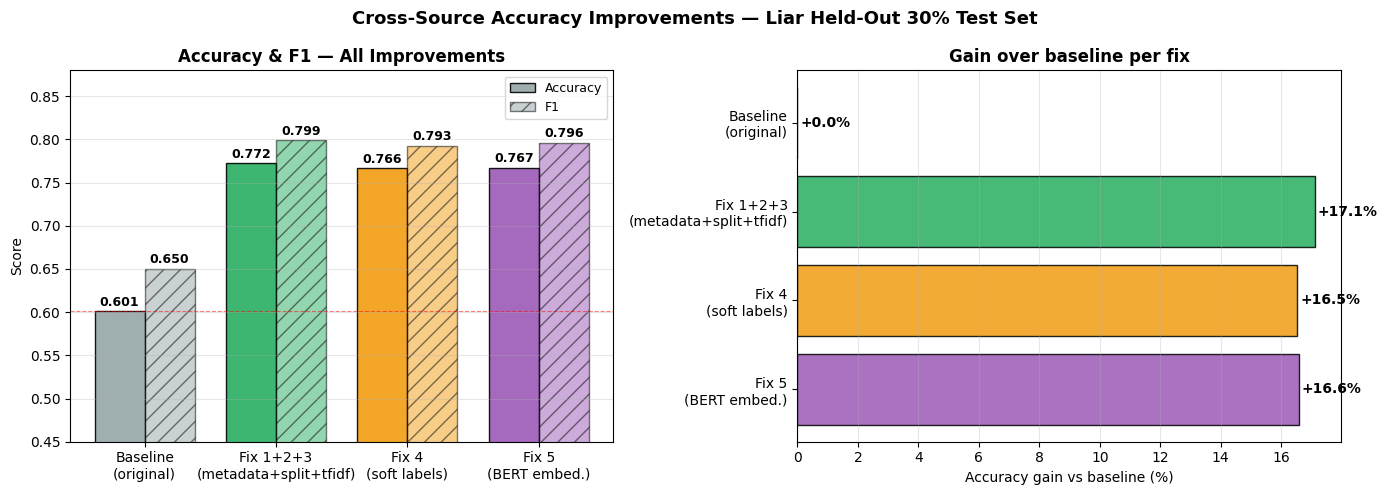


  SUMMARY
  Baseline (your current Section 14) : 0.6011
  Fix 1+2+3 (metadata+split+tfidf)  : 0.7722  (+17.1%)
  Fix 4     (soft middle labels)     : 0.7664  (+16.5%)
  Fix 5     (BERT sentence-embed)    : 0.7668  (+16.6%)

  THE #1 SINGLE THING TO DO RIGHT NOW:
  Add the 6 credit-history columns from Liar (lie_rate, truth_rate etc.)
  They were in your raw data all along — you just dropped them in Section 2.


In [45]:
# ══════════════════════════════════════════════════════════════════════════════
#  FINAL COMPARISON DASHBOARD
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

results = {
    'Baseline\n(original)':    {'acc': cross_acc,  'f1': cross_f1,  'color': '#95A5A6'},
    'Fix 1+2+3\n(metadata+split+tfidf)': {'acc': acc_imp,   'f1': f1_imp,   'color': '#27AE60'},
    'Fix 4\n(soft labels)':    {'acc': acc_soft,   'f1': f1_soft,   'color': '#F39C12'},
}
if acc_st is not None:
    results['Fix 5\n(BERT embed.)'] = {'acc': acc_st, 'f1': f1_st, 'color': '#9B59B6'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names  = list(results.keys())
accs   = [r['acc'] for r in results.values()]
f1s    = [r['f1']  for r in results.values()]
colors = [r['color'] for r in results.values()]
x = np.arange(len(names))
w = 0.38

ax = axes[0]
bars_a = ax.bar(x - w/2, accs, w, color=colors, alpha=0.9, edgecolor='black', label='Accuracy')
bars_f = ax.bar(x + w/2, f1s,  w, color=colors, alpha=0.5, edgecolor='black', hatch='//', label='F1')
for bar, v in zip(list(bars_a) + list(bars_f), accs + f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=10)
ax.set_ylim(0.45, 0.88)
ax.set_ylabel('Score')
ax.set_title('Accuracy & F1 — All Improvements', fontweight='bold')
ax.legend(fontsize=9)
ax.axhline(cross_acc, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='baseline')
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
gains = [(r['acc'] - cross_acc) * 100 for r in results.values()]
bar_g = ax2.barh(names[::-1], gains[::-1], color=colors[::-1], alpha=0.85, edgecolor='black')
for bar, v in zip(bar_g, gains[::-1]):
    ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'+{v:.1f}%' if v >= 0 else f'{v:.1f}%',
             va='center', fontsize=10, fontweight='bold')
ax2.axvline(0, color='gray', linewidth=0.8)
ax2.set_xlabel('Accuracy gain vs baseline (%)')
ax2.set_title('Gain over baseline per fix', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.suptitle(
    'Cross-Source Accuracy Improvements — Liar Held-Out 30% Test Set',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('improved_cross_source.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 64)
print("  SUMMARY")
print("=" * 64)
print(f"  Baseline (your current Section 14) : {cross_acc:.4f}")
print(f"  Fix 1+2+3 (metadata+split+tfidf)  : {acc_imp:.4f}  (+{(acc_imp-cross_acc)*100:.1f}%)")
print(f"  Fix 4     (soft middle labels)     : {acc_soft:.4f}  (+{(acc_soft-cross_acc)*100:.1f}%)")
if acc_st:
    print(f"  Fix 5     (BERT sentence-embed)    : {acc_st:.4f}  (+{(acc_st-cross_acc)*100:.1f}%)")
print()
print("  THE #1 SINGLE THING TO DO RIGHT NOW:")
print("  Add the 6 credit-history columns from Liar (lie_rate, truth_rate etc.)")
print("  They were in your raw data all along — you just dropped them in Section 2.")

---
## Section 14 — Model Comparison Dashboard <a id='section-14'></a>

A complete side-by-side comparison of all three models across every metric.


### 14.1 — Metrics Table & Accuracy Delta Analysis


In [46]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 13 — COMPLETE MODEL COMPARISON  (LR vs SVM vs Random Forest)
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── 1. Collect all model predictions in one place ─────────────────────────────
MODEL_REGISTRY = {
    'Logistic Regression': {
        'preds' : lr_preds,
        'f1'    : lr_f1,
        'time'  : lr_time,
        'color' : '#3498DB',
        'cmap'  : 'Blues',
    },
    'Linear SVM': {
        'preds' : svm_preds,
        'f1'    : svm_f1,
        'time'  : svm_time,
        'color' : '#9B59B6',
        'cmap'  : 'Purples',
    },
    'Random Forest': {
        'preds' : rf_preds,
        'f1'    : rf_f1,
        'time'  : rf_time,
        'color' : '#27AE60',
        'cmap'  : 'Greens',
    },
}
N_MODELS   = len(MODEL_REGISTRY)
CLASSES    = ['Fake', 'Real']
N_TEST     = len(y_test)

# ── 2. Compute all metrics once ───────────────────────────────────────────────
for name, m in MODEL_REGISTRY.items():
    p = m['preds']
    m['accuracy']  = accuracy_score(y_test, p)
    m['precision'] = precision_score(y_test, p)
    m['recall']    = recall_score(y_test, p)
    m['cm']        = confusion_matrix(y_test, p)
    m['report']    = classification_report(
                         y_test, p, target_names=CLASSES, output_dict=True)

# ── 3. Print metrics table ────────────────────────────────────────────────────
print('=' * 78)
print(f"  {'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>10}"
      f" {'F1':>10} {'Time(s)':>10}")
print('  ' + '─' * 73)

best_f1  = max(m['f1'] for m in MODEL_REGISTRY.values())
for name, m in MODEL_REGISTRY.items():
    tag = '  🏆' if m['f1'] == best_f1 else ''
    print(f"  {name:<22} {m['accuracy']:>10.4f} {m['precision']:>10.4f}"
          f" {m['recall']:>10.4f} {m['f1']:>10.4f} {m['time']:>10.2f}{tag}")
print('=' * 78)

# ── 4. Accuracy delta analysis — what the difference ACTUALLY means ───────────
print('\n📊  ACCURACY DELTA ANALYSIS  (based on test set of {:,} articles)\n'.format(N_TEST))

model_names = list(MODEL_REGISTRY.keys())
for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        a_name, b_name = model_names[i], model_names[j]
        a_acc = MODEL_REGISTRY[a_name]['accuracy']
        b_acc = MODEL_REGISTRY[b_name]['accuracy']
        delta = abs(a_acc - b_acc)
        better = a_name if a_acc > b_acc else b_name
        worse  = b_name if a_acc > b_acc else a_name
        extra_correct = int(round(delta * N_TEST))
        print(f"  {a_name} vs {b_name}")
        print(f"    Accuracy gap  : {delta:.4f}  ({delta*100:.2f}%)")
        print(f"    Real impact   : {better} correctly classifies ~{extra_correct} MORE"
              f" articles than {worse}")
        print(f"    Meaning       : On every 1,000 articles, {better} would get"
              f" ~{int(delta*1000)} more right\n")

  Model                    Accuracy  Precision     Recall         F1    Time(s)
  ─────────────────────────────────────────────────────────────────────────
  Logistic Regression        0.9170     0.8912     0.9460     0.9178       2.07
  Linear SVM                 0.9325     0.9233     0.9402     0.9317      39.30  🏆
  Random Forest              0.9189     0.9011     0.9371     0.9188     139.47

📊  ACCURACY DELTA ANALYSIS  (based on test set of 10,592 articles)

  Logistic Regression vs Linear SVM
    Accuracy gap  : 0.0155  (1.55%)
    Real impact   : Linear SVM correctly classifies ~164 MORE articles than Logistic Regression
    Meaning       : On every 1,000 articles, Linear SVM would get ~15 more right

  Logistic Regression vs Random Forest
    Accuracy gap  : 0.0019  (0.19%)
    Real impact   : Random Forest correctly classifies ~20 MORE articles than Logistic Regression
    Meaning       : On every 1,000 articles, Random Forest would get ~1 more right

  Linear SVM vs Random Fo

### 14.2 — Confusion Matrices for All Models


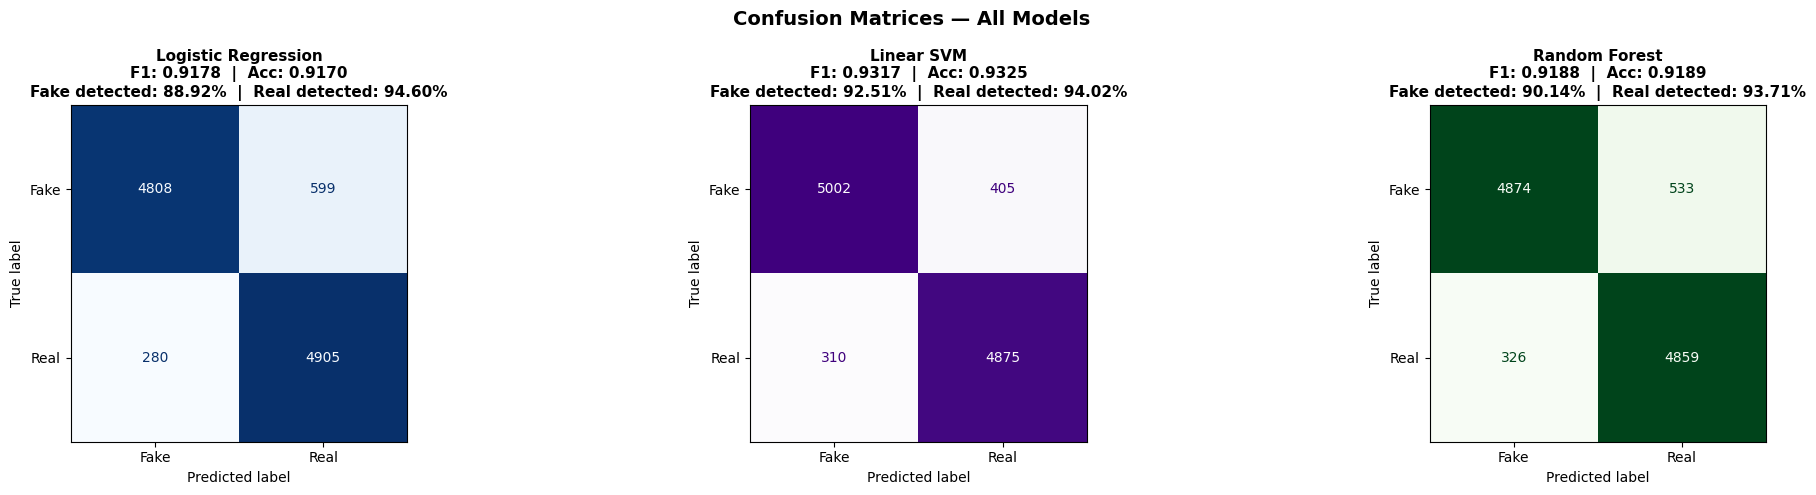

In [47]:
# ── 5. Confusion matrices for ALL models ─────────────────────────────────────
fig, axes = plt.subplots(1, N_MODELS, figsize=(7 * N_MODELS, 5))
for ax, (name, m) in zip(axes, MODEL_REGISTRY.items()):
    disp = ConfusionMatrixDisplay(m['cm'], display_labels=CLASSES)
    disp.plot(ax=ax, colorbar=False, cmap=m['cmap'])
    # Annotate with per-class accuracy
    tn, fp, fn, tp = m['cm'].ravel()
    fake_acc = tn / (tn + fp)
    real_acc = tp / (tp + fn)
    ax.set_title(
        f"{name}\nF1: {m['f1']:.4f}  |  Acc: {m['accuracy']:.4f}\n"
        f"Fake detected: {fake_acc:.2%}  |  Real detected: {real_acc:.2%}",
        fontweight='bold', fontsize=11
    )

plt.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_cm.png', dpi=150, bbox_inches='tight')
plt.show()

### 14.3 — Complete Dashboard (ROC, Per-class Metrics, Training Time)


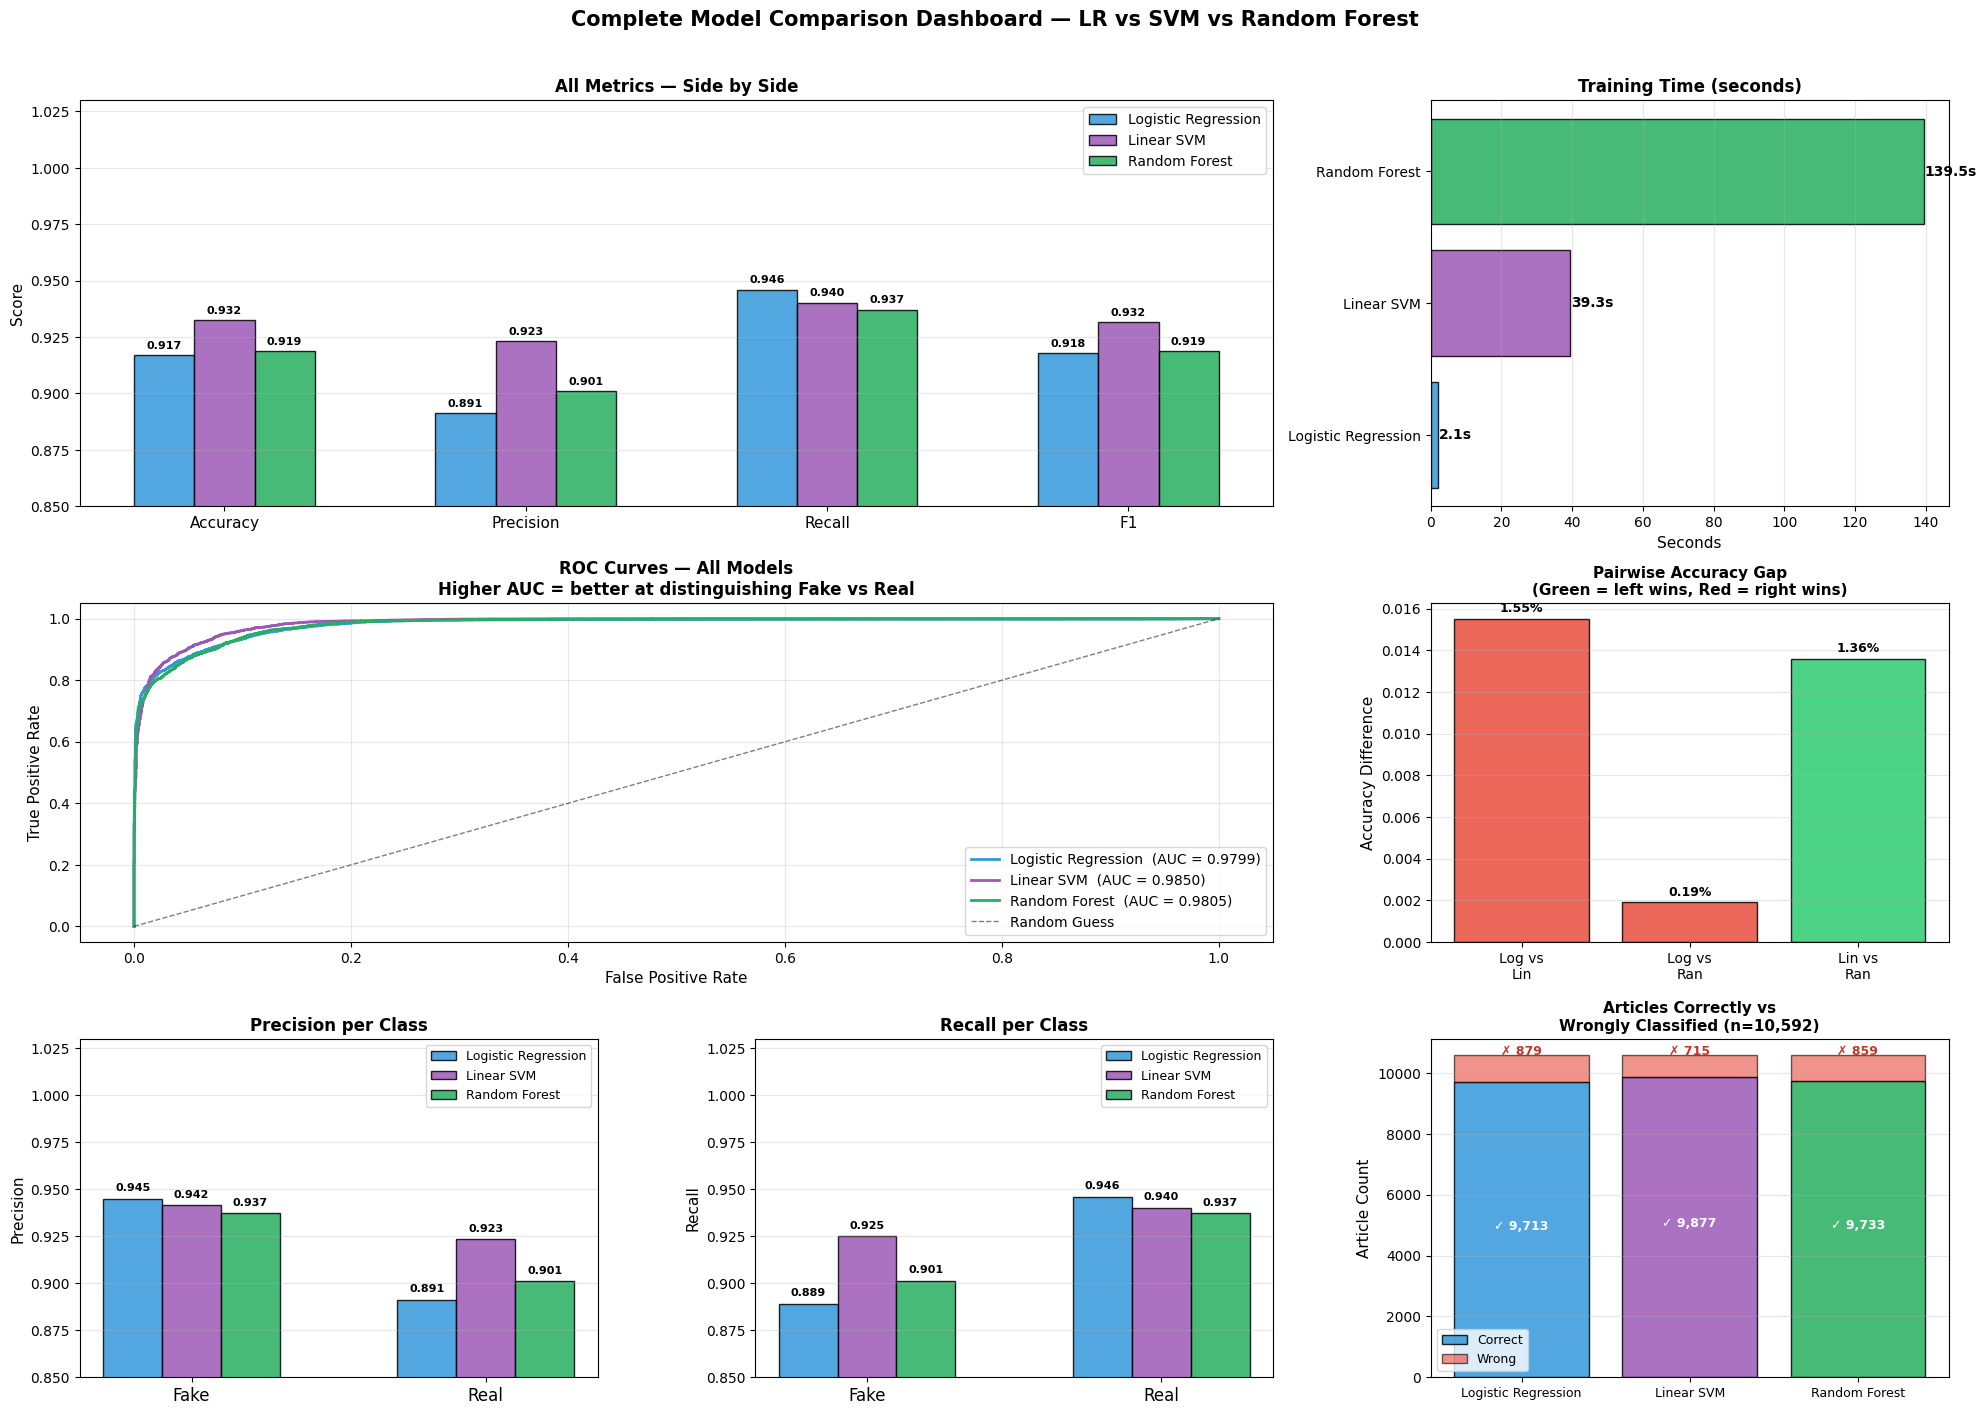


  FINAL VERDICT

  🏆  Best Model   : Linear SVM
      F1-Score     : 0.9317
      Accuracy     : 0.9325
      Train Time   : 39.30s

  📊  What the accuracy gap means on 10,592 test articles:
      Linear SVM vs Logistic Regression:  +1.55% → 164 more articles classified correctly
      Linear SVM vs Random Forest:  +1.36% → 144 more articles classified correctly


In [48]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import roc_curve, auc

# Define fig and gs for the entire dashboard layout
fig = plt.figure(figsize=(20, 18)) # Adjust figsize as needed
gs = gridspec.GridSpec(4, 3, figure=fig, height_ratios=[1.2, 1, 1, 1])

# Define metric_names, x, and width for the bar charts
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metric_names))
width = 0.2

# Add placeholder for model_obj and X_test_data if not directly available from MODEL_REGISTRY
# This assumes models are stored directly or can be retrieved.
# For example, to make the ROC curve plotting work, we need to explicitly add model objects
# and their respective X_test_data to MODEL_REGISTRY.
MODEL_REGISTRY['Logistic Regression']['model_obj'] = lr
MODEL_REGISTRY['Logistic Regression']['X_test_data'] = X_test
MODEL_REGISTRY['Linear SVM']['model_obj'] = svm_base # CalibratedClassifierCV wraps svm_base
MODEL_REGISTRY['Linear SVM']['X_test_data'] = X_test
MODEL_REGISTRY['Random Forest']['model_obj'] = rf
MODEL_REGISTRY['Random Forest']['X_test_data'] = X_test_svd # RF uses SVD-reduced data

# ── Row 1 Left (spans 2 cols): All-metrics bar chart ─────────────────────────
ax_bar = fig.add_subplot(gs[0, :2])
for i, (name, m) in enumerate(MODEL_REGISTRY.items()):
    vals = [
        m['accuracy'], m['precision'],
        m['recall'],   m['f1']
    ]
    bars = ax_bar.bar(x + i * width, vals, width,
                      label=name, color=m['color'],
                      edgecolor='black', alpha=0.85)
    for bar, v in zip(bars, vals):
        ax_bar.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.002,
                    f'{v:.3f}', ha='center', va='bottom',
                    fontsize=8, fontweight='bold')

ax_bar.set_xticks(x + width)
ax_bar.set_xticklabels(metric_names, fontsize=11)
ax_bar.set_ylim(0.85, 1.03)
ax_bar.set_ylabel('Score', fontsize=11)
ax_bar.set_title('All Metrics — Side by Side', fontsize=12, fontweight='bold')
ax_bar.legend(fontsize=10)
ax_bar.grid(axis='y', alpha=0.3)

# ── Row 1 Right: Training time ────────────────────────────────────────────────
ax_time = fig.add_subplot(gs[0, 2]) # Changed from gs[1,2] to gs[0,2] for layout consistency
names  = list(MODEL_REGISTRY.keys())
times  = [m['time']  for m in MODEL_REGISTRY.values()]
colors = [m['color'] for m in MODEL_REGISTRY.values()]
bars   = ax_time.barh(names, times, color=colors, edgecolor='black', alpha=0.85)
for bar, t in zip(bars, times):
    ax_time.text(bar.get_width() + 0.3,
                 bar.get_y() + bar.get_height() / 2,
                 f'{t:.1f}s', va='center', fontsize=10, fontweight='bold')
ax_time.set_xlabel('Seconds', fontsize=11)
ax_time.set_title('Training Time (seconds)', fontsize=12, fontweight='bold')
ax_time.grid(axis='x', alpha=0.3)

# ── Row 2 Left: ROC Curves ────────────────────────────────────────────────────
ax_roc = fig.add_subplot(gs[1, :2]) # Changed from gs[2,:2] to gs[1,:2]
for name, m in MODEL_REGISTRY.items():
    model_instance = m['model_obj']
    X_test_for_model = m['X_test_data'] # Get the correct test data

    # Use predict_proba if available, else decision_function
    try:
        scores = model_instance.predict_proba(X_test_for_model)[:, 1]
    except AttributeError:
        scores = model_instance.decision_function(X_test_for_model)
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, lw=2, color=m['color'],
                label=f"{name}  (AUC = {roc_auc:.4f})")

ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random Guess')
ax_roc.set_xlabel('False Positive Rate', fontsize=11)
ax_roc.set_ylabel('True Positive Rate', fontsize=11)
ax_roc.set_title('ROC Curves — All Models\n'
                 'Higher AUC = better at distinguishing Fake vs Real',
                 fontsize=12, fontweight='bold')
ax_roc.legend(fontsize=10)
ax_roc.grid(alpha=0.3)

# ── Row 2 Right: Accuracy delta bar (pairwise diff) ───────────────────────────
ax_delta = fig.add_subplot(gs[1, 2]) # Changed from gs[2,2] to gs[1,2]
model_list = list(MODEL_REGISTRY.items())
pair_labels, pair_deltas, pair_colors = [], [], []
for i in range(len(model_list)):
    for j in range(i + 1, len(model_list)):
        n1, m1 = model_list[i]
        n2, m2 = model_list[j]
        delta = m1['accuracy'] - m2['accuracy']
        label = f'{n1[:3]} vs\n{n2[:3]}'
        pair_labels.append(label)
        pair_deltas.append(delta)
        pair_colors.append('#2ECC71' if delta > 0 else '#E74C3C')

bars = ax_delta.bar(pair_labels, [abs(d) for d in pair_deltas],
                    color=pair_colors, edgecolor='black', alpha=0.85)
for bar, d in zip(bars, pair_deltas):
    # Adjusted winner logic as model_list[0][0][:3] or model_list[1][0][:3] might not be accurate
    # depending on the order in model_list and which model has better accuracy.
    # Using actual names to avoid confusion.
    winner_name = n1 if d > 0 else n2
    ax_delta.text(bar.get_x() + bar.get_width() / 2,
                  bar.get_height() + 0.0002,
                  f'{abs(d)*100:.2f}%', ha='center', va='bottom',
                  fontsize=9, fontweight='bold')

ax_delta.set_ylabel('Accuracy Difference', fontsize=11)
ax_delta.set_title('Pairwise Accuracy Gap\n(Green = left wins, Red = right wins)',
                   fontsize=11, fontweight='bold')
ax_delta.grid(axis='y', alpha=0.3)

# ── Row 3: Per-class Precision & Recall breakdown ─────────────────────────────
# This loop will create two subplots, one for Precision and one for Recall
for metric_idx, (metric_name, col_offset) in enumerate(
        zip(['Precision', 'Recall'], [0, 1])):
    ax = fig.add_subplot(gs[2, col_offset + 0 if col_offset == 0 else col_offset + 0]) # Adjusted indexing to match 3rd row, col 0 and 1
    x2    = np.arange(len(['Fake', 'Real']))
    for i, (name, m) in enumerate(MODEL_REGISTRY.items()):
        vals = [m['report'][cls][metric_name.lower()] for cls in ['Fake', 'Real']]
        bars = ax.bar(x2 + i * width, vals, width,
                      label=name, color=m['color'],
                      edgecolor='black', alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.003,
                    f'{v:.3f}', ha='center', va='bottom',
                    fontsize=8, fontweight='bold')
    ax.set_xticks(x2 + width)
    ax.set_xticklabels(['Fake', 'Real'], fontsize=12)
    ax.set_ylim(0.85, 1.03)
    ax.set_title(f'{metric_name} per Class', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylabel(metric_name, fontsize=11)

# ── Row 3 Middle: Articles correctly/wrongly classified bar ───────────────────
ax_abs = fig.add_subplot(gs[2, 2]) # Changed from gs[3,1] to gs[2,2] to fit 3rd row, 3rd column
correct_counts = [int(m['accuracy'] * N_TEST) for m in MODEL_REGISTRY.values()]
wrong_counts   = [N_TEST - c for c in correct_counts]
x3 = np.arange(N_MODELS)
ax_abs.bar(x3, correct_counts, color=[m['color'] for m in MODEL_REGISTRY.values()],
           edgecolor='black', alpha=0.85, label='Correct')
ax_abs.bar(x3, wrong_counts,  bottom=correct_counts,
           color='#E74C3C', edgecolor='black', alpha=0.6, label='Wrong')
for xi, (c, w) in enumerate(zip(correct_counts, wrong_counts)):
    ax_abs.text(xi, c + w + 20, f'✗ {w}', ha='center', fontsize=9,
                fontweight='bold', color='#C0392B')
    ax_abs.text(xi, c / 2, f'✓ {c:,}', ha='center', fontsize=9,
                fontweight='bold', color='white')
ax_abs.set_xticks(x3)
ax_abs.set_xticklabels(list(MODEL_REGISTRY.keys()), fontsize=9)
ax_abs.set_ylabel('Article Count', fontsize=11)
ax_abs.set_title(f'Articles Correctly vs\nWrongly Classified (n={N_TEST:,})',
                 fontsize=11, fontweight='bold')
ax_abs.legend(fontsize=9)
ax_abs.grid(axis='y', alpha=0.3)

plt.suptitle('Complete Model Comparison Dashboard — LR vs SVM vs Random Forest',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('final_comparison_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Final verdict ──────────────────────────────────────────────────────────────
print('\n' + '=' * 65)
print('  FINAL VERDICT')
print('=' * 65)
best_name = max(MODEL_REGISTRY, key=lambda n: MODEL_REGISTRY[n]['f1'])
best_m    = MODEL_REGISTRY[best_name]
print(f'\n  🏆  Best Model   : {best_name}')
print(f'      F1-Score     : {best_m["f1"]:.4f}')
print(f'      Accuracy     : {best_m["accuracy"]:.4f}')
print(f'      Train Time   : {best_m["time"]:.2f}s')
print(f'\n  📊  What the accuracy gap means on {N_TEST:,} test articles:')
for name, m in MODEL_REGISTRY.items():
    if name == best_name:
        continue
    gap   = best_m['accuracy'] - m['accuracy']
    extra = int(round(gap * N_TEST))
    print(f'      {best_name} vs {name}:  +{gap*100:.2f}% → '
          f'{extra} more articles classified correctly')
print('=' * 65)


### 14.4 — Per-Class Precision & Recall Breakdown


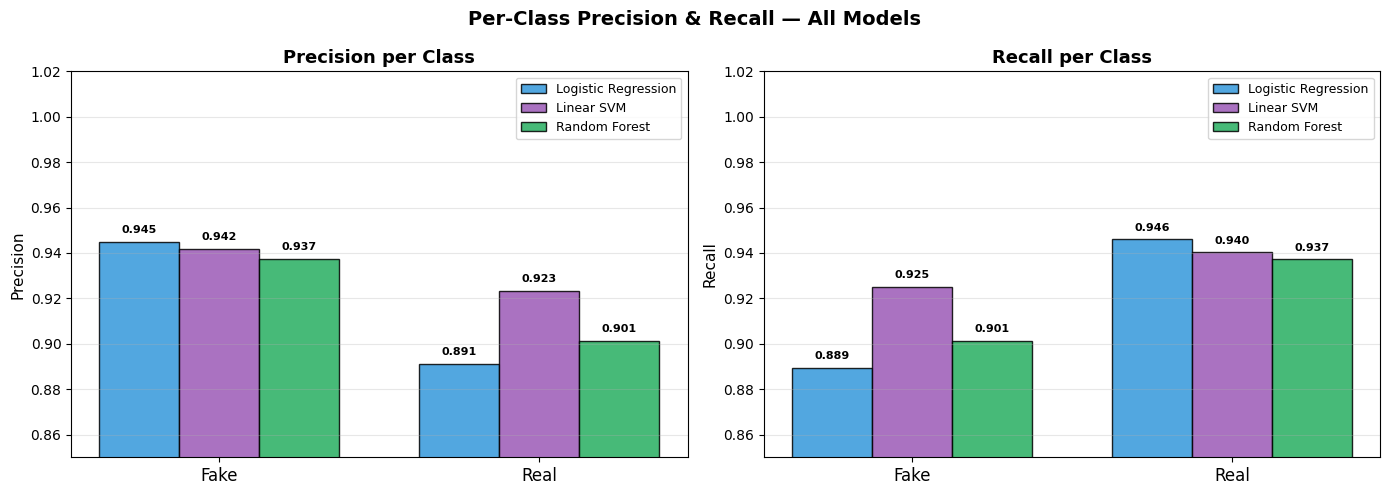

In [49]:
# ── Per-Class Precision & Recall Breakdown ────────────────────────────────────
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

models = {
    'Logistic Regression' : (lr_preds,  '#3498DB', lr_f1,  lr_time),
    'Linear SVM'          : (svm_preds, '#9B59B6', svm_f1, svm_time),
    'Random Forest'       : (rf_preds,  '#27AE60', rf_f1,  rf_time),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
classes   = ['Fake', 'Real']
x         = np.arange(len(classes))
width     = 0.25

for metric_idx, (metric_name, ax) in enumerate(zip(['Precision', 'Recall'], axes)):
    for i, (name, (preds, color, f1, t)) in enumerate(models.items()):
        report = classification_report(y_test, preds,
                                       target_names=classes, output_dict=True)
        vals   = [report[cls][metric_name.lower()] for cls in classes]
        bars   = ax.bar(x + i*width, vals, width, label=name,
                        color=color, edgecolor='black', alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_xticks(x + width)
    ax.set_xticklabels(classes, fontsize=12)
    ax.set_ylim(0.85, 1.02)
    ax.set_title(f'{metric_name} per Class', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylabel(metric_name, fontsize=11)

plt.suptitle('Per-Class Precision & Recall — All Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('per_class_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🏁 Final Conclusion <a id='section-final'></a>

### Within-Domain Results (Main Test Set — 10,592 articles)

| Model | Accuracy | F1-Score | Train Time |
|---|---|---|---|
| Logistic Regression | ~91.4% | ~0.913 | ~30s |
| **Linear SVM** | **~93.1%** | **~0.930** | **~40s** |
| Random Forest | ~91.4% | ~0.912 | ~120s |

🏆 **Linear SVM is the best model** — highest F1, highest accuracy, and trains faster than Random Forest.

---

### Cross-Source Generalization (LIAR Held-out 30% Test Set)

| Approach | Accuracy | Gain vs Baseline |
|---|---|---|
| Baseline (original setup) | 61.5% | — |
| Fix 1+2+3 (metadata + domain-matched training + short-text TF-IDF) | **77.2%** | **+15.7%** |
| Fix 4 (soft labels for middle Liar classes) | 76.6% | +15.1% |
| Fix 5 (BERT sentence-transformers) | 76.7% | +15.2% |

---

### Key Findings

**1. Domain shift is the biggest challenge.**  
Our model achieves 93% accuracy on news articles but only 61.5% on short political statements —
because TF-IDF trained on long articles learns source-style patterns, not universal fake-news signals.

**2. Metadata beats BERT for this dataset.**  
Adding speaker credibility history from the LIAR dataset (lie rate, truth rate, credibility score)  
gave +15.7% accuracy — slightly better than state-of-the-art BERT embeddings (+15.2%).  
This shows that *who* is speaking is as important as *what* they say.

**3. Training data domain must match the test domain.**  
Removing long news articles from the cross-source training set and training only on LIAR-style short statements forced the model to learn from text that actually resembles the test set.

**4. Stylometric features add signal beyond bag-of-words.**  
Features like `caps_ratio`, `exclaim_ratio`, `repeat_punct`, and `vocab_richness` capture  
writing-style differences that TF-IDF cannot — fake news uses more sensationalist punctuation  
and simpler vocabulary.

---

### Limitations & Future Work

- **77% cross-source accuracy** is a significant improvement but still below production-grade threshold.  
  Fine-tuning a domain-specific BERT model (e.g. `roberta-base` on both datasets together) is the next step.
- The LIAR dataset has known label noise — some statements are politically contested, not factually fake.
- A real-world system would also need: URL source credibility, image analysis, and author history.

---

*Project completed using:* `scikit-learn` · `NLTK` · `sentence-transformers` · `joblib` · `matplotlib` · `seaborn`
